In [152]:
#pd.set_option('display.max_rows', None)
import numpy as np
import pandas as pd
import bokeh
import hvplot.pandas
import holoviews as hv
import bokeh.palettes
from bokeh.plotting import figure, show, output_notebook

import neuprint

import importlib
import lib as cl
from lib import syn_specs
from neuprint import SynapseCriteria

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib as mpl

import napari
from aicsimageio import AICSImage
from skimage import measure
import tifffile as tf
import xarray as xr
from tifffile import tifffile
import tifftools
import os
from os.path import sep
from skimage import io
from PIL import Image
import imageio
from skimage.measure import regionprops_table
import seaborn as sns
import czifile
import math
from pathlib import Path
import re
from bokeh.io import output_notebook, show as bokeh_show
output_notebook(hide_banner=True)
show = bokeh_show 

import itertools
from scipy.optimize import curve_fit, least_squares

from typing import Dict, Iterable, List, Optional


<font size="10">PART ONE</font>

# all delta7-->each delta7

# connectome part

In [192]:
data_dir = Path("csv_25summer") / "csv_all_d7_upstreams"

csv_files = sorted(data_dir.glob('*.csv'))

all_d7_upstream_results = {
    f.stem: pd.read_csv(f)
    for f in csv_files
}
'''
for name, df in all_d7_upstream_results.items():
    print(name, df.shape)
'''
len(all_d7_upstream_results)

42

In [193]:
def reorder_pb_glomeruli_for(tag: str, env=None, *, verbose: bool=False, return_dict: bool=False):
    """
    Reorder rows in all_<tag>_upstream_results so they go:
      PB(L9) ... PB(L1) PB(R1) ... PB(R9)

    Creates all_<tag>_upstream_results_reordered and ALSO overwrites all_<tag>_upstream_results.
    By default prints nothing and returns nothing to avoid giant output in notebooks.

    Parameters
    ----------
    tag : {'d7','lpsp','p1-9','p19'}
    env : dict-like namespace where variables live (defaults to globals()).
    verbose : bool, if True prints a short summary and any warnings.
    return_dict : bool, if True returns the reordered dict; otherwise returns None.
    """
    # normalize tag → variable suffix
    key = tag.strip().lower().replace("p1-9", "p19")
    suffix_map = {"d7": "d7", "lpsp": "lpsp", "p19": "p19"}
    if key not in suffix_map:
        raise ValueError("tag must be one of {'d7','lpsp','p1-9'/'p19'}")
    suffix = suffix_map[key]

    in_name  = f"all_{suffix}_upstream_results"
    out_name = f"all_{suffix}_upstream_results_reordered"

    # where to look for the dict variables
    env = globals() if env is None else env
    if in_name not in env or not isinstance(env[in_name], dict):
        raise NameError(f"Expected a dict named '{in_name}' in scope.")

    dfs_dict = env[in_name]

    # desired top→bottom order
    desired = [f"PB(L{i})" for i in range(9, 0, -1)] + [f"PB(R{i})" for i in range(1, 10)]

    out, skipped = {}, []
    for name, df in dfs_dict.items():
        # find glomerulus column
        gcol = 'Glomerulus' if 'Glomerulus' in df.columns else ('glomerulus' if 'glomerulus' in df.columns else None)
        if gcol is None:
            skipped.append(name)
            continue

        tmp = df.copy()
        tmp[gcol] = tmp[gcol].astype(str)
        tmp['__ord'] = pd.Categorical(tmp[gcol], categories=desired, ordered=True)
        tmp = tmp.sort_values('__ord').drop(columns='__ord').reset_index(drop=True)
        out[name] = tmp

    # expose results under requested variable names
    env[out_name] = out
    env[in_name] = out  # overwrite original, per your request

    if verbose:
        if skipped:
            print(f"[warn] skipped {len(skipped)} items without a Glomerulus column (e.g., {skipped[:3]})")
        print(f"[ok] Reordered {len(out)} DataFrames -> '{out_name}', and overwrote '{in_name}'.")

    if return_dict:
        return out

In [194]:
reorder_pb_glomeruli_for("d7")

In [195]:
all_d7_upstream_results['delta7_1158747783_L7R2_L_upstream']

,Glomerulus,SynapseCount
0,PB(L9),13
1,PB(L8),9
2,PB(L7),27
3,PB(L6),15
4,PB(L5),43
5,PB(L4),81
6,PB(L3),83
7,PB(L2),29
8,PB(L1),45
9,PB(R1),2


In [196]:
def split_halves(source_dict):
    halves = {}
    for name, df in source_dict.items():
        df_first  = df.iloc[:9].reset_index(drop=True)
        df_second = df.iloc[9:].reset_index(drop=True)
        halves[f"{name}_L"] = df_first
        halves[f"{name}_R"] = df_second
    return halves

all_d7_upstream_results_halves = split_halves(all_d7_upstream_results)

In [197]:
def combine_1_9_connectome(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for side in ['L', 'R']:
        g1, g9 = f'PB({side}1)', f'PB({side}9)'
        idx1 = df.index[df['Glomerulus'] == g1]
        idx9 = df.index[df['Glomerulus'] == g9]

        # Only combine if both rows exist
        if len(idx1) > 0 and len(idx9) > 0:
            i1, i9 = idx1[0], idx9[0]             # indices of the '1' and '9' rows
            rows = df.loc[[i1, i9]]               # two-row slice

            # Build the combined values
            new_glom        = f'PB({side}1+9)'
            new_sc = rows['SynapseCount'].sum()

            # Placement/drop rule:
            # - For 'R': put new row where '1' was, drop the '9' row
            # - For 'L': put new row where '9' was, drop the '1' row
            keep_idx = i1 if side == 'R' else i9
            drop_idx = i9 if side == 'R' else i1

            # Overwrite the kept row with combined values
            df.loc[keep_idx, 'Glomerulus'] = new_glom
            df.loc[keep_idx, 'SynapseCount']   = new_sc

            # Drop the other row
            df = df.drop(index=drop_idx)

    return df

In [198]:
all_d7_upstream_results_halves_combine19 = {
    f"{name}_combine19": combine_1_9_connectome(df)
    for name, df in all_d7_upstream_results_halves.items()
}

In [199]:
all_d7_upstream_results_halves['delta7_5813061383_L1L9R8_R_upstream_L']

,Glomerulus,SynapseCount
0,PB(L9),32
1,PB(L8),9
2,PB(L7),32
3,PB(L6),43
4,PB(L5),40
5,PB(L4),84
6,PB(L3),33
7,PB(L2),7
8,PB(L1),58


In [200]:
all_d7_upstream_results_halves_combine19['delta7_910783731_L8R1R9_L_upstream_R_combine19']

,Glomerulus,SynapseCount
0,PB(R1+9),89
1,PB(R2),14
2,PB(R3),36
3,PB(R4),50
4,PB(R5),45
5,PB(R6),43
6,PB(R7),46
7,PB(R8),7


In [201]:
delta7_naming = pd.read_csv('neuprint_delta7_names.csv')
def build_subtype_parts(delta7_naming: pd.DataFrame) -> pd.DataFrame:
    # --- Step 1: keep only id and instance
    df = delta7_naming.loc[:, ["id", "instance"]].copy()

    # --- Step 2: remove the last two characters from instance -> call it 'subtype'
    # e.g., "L1L9R8_R" -> "L1L9R8"
    df["subtype"] = df["instance"].str.slice(0, -2)

    # --- Step 3: tokenize every 2-character (L/R + digits) group into part1, part2, ...
    # handles 2- or 3-glomerulus strings, e.g., "L1L9R8" or "L8R1R9"
    tokens = df["subtype"].str.findall(r"[LR]\d+")
    max_parts = tokens.map(len).max()
    col_names = [f"part{i+1}" for i in range(max_parts)]
    df[col_names] = pd.DataFrame(tokens.tolist(), index=df.index)

    # --- Step 4: special rewrites
    # Case m1: subtype == 'L1L9R8'
    #   part1 -> part1 + '+' + last digit of part2  (L1 -> L1+9)
    #   part2 -> part3 (move R8 over)
    m1 = df["subtype"].eq("L1L9R8")
    if "part3" in df.columns:
        df.loc[m1, "part1"] = df.loc[m1, "part1"] + "+" + df.loc[m1, "part2"].str[-1]
        df.loc[m1, "part2"] = df.loc[m1, "part3"]

    # Case m2: subtype == 'L8R1R9'
    #   part2 -> part2 + '+' + last digit of part3 (R1 -> R1+9)
    m2 = df["subtype"].eq("L8R1R9")
    if "part3" in df.columns:
        df.loc[m2, "part2"] = df.loc[m2, "part2"] + "+" + df.loc[m2, "part3"].str[-1]

    # Drop part3 (per your example), if it exists
    if "part3" in df.columns:
        df = df.drop(columns=["part3"])

    for col in ["part1", "part2"]:
        mask = df[col].notna()
        df.loc[mask, col] = "PB(" + df.loc[mask, col].astype(str) + ")"

    # Return just the useful columns
    return df.loc[:, ["id", "subtype", "part1", "part2"]]

In [202]:
neuron_subtype = build_subtype_parts(delta7_naming)
neuron_subtype[:5]

,id,subtype,part1,part2
0,911911004,L1L9R8,PB(L1+9),PB(R8)
1,911919917,L1L9R8,PB(L1+9),PB(R8)
2,5813061383,L1L9R8,PB(L1+9),PB(R8)
3,911574261,L1L9R8,PB(L1+9),PB(R8)
4,881221166,L1L9R8,PB(L1+9),PB(R8)


In [203]:
def reorder_halves_combine19_connectome(original_halves_combine19: dict, neuron_subtype: pd.DataFrame = neuron_subtype, target_idx: int = 4):
    """
    Reorder each DF in original_halves_combine19 so that the row whose
    'glomerulus' matches the 'center' (from neuron_subtype part1/part2) is moved
    to the desired target index (default 4, i.e., 5th row).
    
    Returns a new dict named original_halves_combine19_reordered.
    """
    parts_lookup = neuron_subtype.set_index("id")[["part1", "part2"]].to_dict("index")  # changed to ("id")!!!
    original_halves_combine19_reordered = {}

    for name, df in original_halves_combine19.items():
        # Determine which part (center) to use based on side in the name
        base_name = name.split("_")[1]                          # e.g., "delta7_1158747783_L7R2_L_upstream_L_combine19" --> "1158747783"
        base_name_int = int(base_name)
        side_name = name.split("_")[5]
        column_to_look = "part1" if "L" in side_name else "part2"   # left uses part1, right uses part2

        parts = parts_lookup.get(base_name_int)
        if parts is None:
            continue

        center = parts.get(column_to_look)                      # e.g., "PB(R4)" or "PB(L3)"
        if pd.isna(center):
            continue

        # find the row index where glomerulus == center
        idxs = df.index[df["Glomerulus"] == center]
        if len(idxs) == 0:
            # nothing to reorder if we don't find a matching center row
            continue

        current_idx = int(idxs[0])

        # roll row order so that current_idx moves to target_idx
        shift = target_idx - current_idx
        order = np.roll(np.arange(len(df)), shift)
        df_reordered = df.iloc[order].reset_index(drop=True)

        original_halves_combine19_reordered[f"{name}_reordered"] = df_reordered

    return original_halves_combine19_reordered

In [204]:
reordered_dfs_d7 = reorder_halves_combine19_connectome(all_d7_upstream_results_halves_combine19, neuron_subtype)

In [205]:
reordered_dfs_d7['delta7_1158747783_L7R2_L_upstream_L_combine19_reordered']

,Glomerulus,SynapseCount
0,PB(L3),83
1,PB(L2),29
2,PB(L1+9),58
3,PB(L8),9
4,PB(L7),27
5,PB(L6),15
6,PB(L5),43
7,PB(L4),81


In [206]:
def add_percentage_synapse_count(
    dfs: Dict[str, pd.DataFrame],
    *,
    count_col: str = "SynapseCount",
    new_col: str = "percentage_SynapseCount"
) -> Dict[str, pd.DataFrame]:
    """
    For each DataFrame in `dfs`, compute percentage_SynapseCount = SynapseCount / max(SynapseCount).
    Returns a new dict with the same keys. If SynapseCount is missing or all <= 0, fills 0.0.
    """
    out = {}
    for name, df in dfs.items():
        if not isinstance(df, pd.DataFrame) or df.empty or count_col not in df.columns:
            out[name] = df
            continue

        base = df.copy()
        s = pd.to_numeric(base[count_col], errors="coerce")
        m = s.max(skipna=True)

        if pd.isna(m) or m <= 0:
            base[new_col] = 0.0
        else:
            base[new_col] = (s / m).astype(float)

        out[name] = base
    return out

In [207]:
reordered_dfs_d7 = add_percentage_synapse_count(reordered_dfs_d7)

In [208]:
reordered_dfs_d7['delta7_1158747783_L7R2_L_upstream_L_combine19_reordered']

,Glomerulus,SynapseCount,percentage_SynapseCount
0,PB(L3),83,1.000000
1,PB(L2),29,0.349398
2,PB(L1+9),58,0.698795
3,PB(L8),9,0.108434
4,PB(L7),27,0.325301
5,PB(L6),15,0.180723
6,PB(L5),43,0.518072
7,PB(L4),81,0.975904


In [209]:
def make_add1row_versions(
    dfs: Dict[str, pd.DataFrame],
    *,
    glomerulus_col: str = "Glomerulus",
    metric_cols: Iterable[str] = ("SynapseCount", "percentage_SynapseCount"),
    suffix: str = "_add1row",
) -> Dict[str, pd.DataFrame]:
    """
    For each DataFrame in `dfs`, append a new bottom row where:
      - Glomerulus = "added"
      - each metric in `metric_cols` copies the value from the first row (index 0)

    Returns a NEW dict with keys '<old_key>_add1row'.
    """
    out: Dict[str, pd.DataFrame] = {}

    for name, df in dfs.items():
        if not isinstance(df, pd.DataFrame) or df.empty:
            continue

        base = df.reset_index(drop=True).copy()

        # ensure the glomerulus column exists
        if glomerulus_col not in base.columns:
            base[glomerulus_col] = pd.NA

        # build the new row as a dict with same columns
        new_row = {c: pd.NA for c in base.columns}
        new_row[glomerulus_col] = "added"

        # copy metrics from the first row
        for c in metric_cols:
            if c in base.columns:
                new_row[c] = base.loc[0, c]

        # append to bottom
        df_new = pd.concat([base, pd.DataFrame([new_row], columns=base.columns)], ignore_index=True)

        out[f"{name}{suffix}"] = df_new

    return out

In [210]:
dict_all_halves_commectome = make_add1row_versions(reordered_dfs_d7)

In [211]:
dict_all_halves_commectome['delta7_1158747783_L7R2_L_upstream_L_combine19_reordered_add1row']

,Glomerulus,SynapseCount,percentage_SynapseCount
0,PB(L3),83,1.000000
1,PB(L2),29,0.349398
2,PB(L1+9),58,0.698795
3,PB(L8),9,0.108434
4,PB(L7),27,0.325301
5,PB(L6),15,0.180723
6,PB(L5),43,0.518072
7,PB(L4),81,0.975904
8,added,83,1.000000


In [212]:
# this cell create a summed and averaged summary df from the given dict (for now should be {reordered_2glo_some3glo_halves_d7})
# it creates the sum and mean of the "SynapseCount" column from all the df in the input dict.
# it also creates the sum and mean of the "percentage_SynapseCount" column from all df in the dict.
# NOTE: in the summary df, "percentage_SynapseCount_mean" column is first sum then average all the "percentage_SynapseCount" column,
#    while the "percentage_SynapseCount_NEW" is use the "SynapseCount" column from THIS SUMMARY DF and get the percentage (divide each entry by the max in thie column)

def sum_and_mean_synapse_counts(
    dfs_dict: dict[str, pd.DataFrame],
    column: str = "SynapseCount",
    make_glomerulus_labels: bool = True,
) -> pd.DataFrame:
    """
    Sum and average the per-row values in `column` AND in `percentage_<column>` across all DataFrames.

    Returns a DataFrame with:
      ['glomerulus',
       column, f'{column}_mean',
       f'percentage_{column}', f'percentage_{column}_mean',
       'percentage_SynapseCount_NEW']  # (sum of `column`) / (max of sum of `column`)
    """
    if not dfs_dict:
        raise ValueError("Input dictionary is empty.")

    perc_col = f"percentage_{column}"

    series_main = []
    series_perc = []
    nrows = None

    for name, df in dfs_dict.items():
        # main column
        if column not in df.columns:
            raise ValueError(f"'{column}' not found in DataFrame '{name}'.")
        s_main = pd.to_numeric(df[column], errors="coerce").reset_index(drop=True)

        # row count consistency
        if nrows is None:
            nrows = len(s_main)
        elif len(s_main) != nrows:
            raise ValueError(f"Row count mismatch in '{name}': expected {nrows}, got {len(s_main)}")

        series_main.append(s_main)

        # percentage column
        if perc_col not in df.columns:
            raise ValueError(f"'{perc_col}' not found in DataFrame '{name}'.")
        s_perc = pd.to_numeric(df[perc_col], errors="coerce").reset_index(drop=True)

        if len(s_perc) != nrows:
            raise ValueError(f"Row count mismatch for '{perc_col}' in '{name}': expected {nrows}, got {len(s_perc)}")

        series_perc.append(s_perc)

    # Concatenate
    mat_main = pd.concat(series_main, axis=1)
    mat_perc = pd.concat(series_perc, axis=1)

    # Row-wise sum and mean (mean over non-NaN contributors)
    sum_main  = mat_main.sum(axis=1, skipna=True)
    n_main    = mat_main.notna().sum(axis=1)
    mean_main = sum_main.divide(n_main).where(n_main > 0)

    sum_perc  = mat_perc.sum(axis=1, skipna=True)
    n_perc    = mat_perc.notna().sum(axis=1)
    mean_perc = sum_perc.divide(n_perc).where(n_perc > 0)

    # Glomerulus labels
    if make_glomerulus_labels:
        n = len(sum_main)
        if n % 2 != 1:
            raise ValueError(f"Expected an odd number of rows (e.g., 9), got {n}.")
        half = n // 2
        glomerulus = list(range(-half, half + 1))
    else:
        glomerulus = list(range(len(sum_main)))
    
    # now the df is generated
    out = pd.DataFrame({
        "glomerulus": glomerulus,
        column: sum_main.values,
        f"{column}_mean": mean_main.values,
        perc_col: sum_perc.values,
        f"{perc_col}_mean": mean_perc.values,
    })

    # Normalize summed `column` within this new DF (fraction of max of the summed series)
    s = pd.to_numeric(out[column], errors="coerce")
    m = s.max(skipna=True)
    out["percentage_SynapseCount_mean_NEW"] = np.where(np.isfinite(m) & (m != 0), s / m, 0.0).astype(float)

    return out

In [213]:
summarydf_all_halves_commectome = sum_and_mean_synapse_counts(dict_all_halves_commectome, column="SynapseCount")
# this is the "sum_2glo_some3glo_halves_d7" in the previous notebook

In [214]:
summarydf_all_halves_commectome

,glomerulus,SynapseCount,SynapseCount_mean,percentage_SynapseCount,percentage_SynapseCount_mean,percentage_SynapseCount_mean_NEW
0,-4,3733,44.440476,54.075465,0.643756,0.938175
1,-3,3920,46.666667,56.413211,0.671586,0.985172
2,-2,2845,33.869048,42.544946,0.506487,0.715004
3,-1,1769,21.059524,28.104556,0.334578,0.444584
4,0,3639,43.321429,54.962380,0.654314,0.914551
5,1,1774,21.119048,27.240587,0.324293,0.445841
6,2,2817,33.535714,41.683586,0.496233,0.707967
7,3,3979,47.369048,58.320960,0.694297,1.000000
8,4,3733,44.440476,54.075465,0.643756,0.938175


In [215]:
def plot_individual_vs_population_connectome(
    indiv_dict,
    pop_df,
    line_color="tab:blue",
    title=None,
    *,
    metric="SynapseCount",                 # "SynapseCount" or "percentage_SynapseCount"
    mean_version="old"                     # when metric is percentage: "old" or "new"
):
    """
    Plot individual traces (thin gray) and population mean (thick colored).

    Parameters
    ----------
    indiv_dict : dict[str, pd.DataFrame]
        Each DataFrame must contain the chosen `metric` column.
    pop_df : pd.DataFrame
        Must contain population columns depending on `metric`:
          - metric="SynapseCount" -> needs 'SynapseCount_mean'
          - metric="percentage_SynapseCount":
              mean_version="old" -> needs 'percentage_SynapseCount_mean'
              mean_version="new" -> prefers 'percentage_SynapseCount_mean_NEW';
                                    if missing, computes SynapseCount_mean / max(SynapseCount_mean)
    line_color : str
        Color for the population mean line.
    title : str or None
        Plot title.
    metric : str
        "SynapseCount" or "percentage_SynapseCount"
    mean_version : str
        Only used if metric == "percentage_SynapseCount". One of {"old","new"}.
    """
    if not indiv_dict:
        raise ValueError("indiv_dict is empty.")

    metric = str(metric)
    if metric not in {"SynapseCount", "percentage_SynapseCount"}:
        raise ValueError("metric must be 'SynapseCount' or 'percentage_SynapseCount'.")

    # figure out population column to use
    if metric == "SynapseCount":
        pop_col = "SynapseCount_mean"
        if pop_col not in pop_df.columns:
            raise ValueError(f"pop_df must contain '{pop_col}'.")
        y_pop_raw = pd.to_numeric(pop_df[pop_col], errors="coerce")
        pop_label = "population (SynapseCount_mean)"
    else:
        # percentage_SynapseCount
        mean_version = str(mean_version).lower()
        if mean_version not in {"old", "new"}:
            raise ValueError("mean_version must be 'old' or 'new' when metric='percentage_SynapseCount'.")

        if mean_version == "old":
            pop_col = "percentage_SynapseCount_mean"
            if pop_col not in pop_df.columns:
                raise ValueError(f"pop_df must contain '{pop_col}' for mean_version='old'.")
            y_pop_raw = pd.to_numeric(pop_df[pop_col], errors="coerce")
            pop_label = "population (percentage_SynapseCount_mean)"
        else:
            # "new": prefer precomputed column; else compute normalized SynapseCount_mean
            if "percentage_SynapseCount_mean_NEW" in pop_df.columns:
                y_pop_raw = pd.to_numeric(pop_df["percentage_SynapseCount_mean_NEW"], errors="coerce")
                pop_label = "population (percentage_SynapseCount_mean_NEW)"
            else:
                if "SynapseCount_mean" not in pop_df.columns:
                    raise ValueError("pop_df must contain 'SynapseCount_mean' to compute NEW version.")
                scm = pd.to_numeric(pop_df["SynapseCount_mean"], errors="coerce")
                m = scm.max(skipna=True)
                y_pop_raw = (scm / m) if (np.isfinite(m) and m != 0) else scm * 0
                pop_label = "population (SynapseCount_mean / max)"

    # Common length (truncate to shortest)
    lengths = [len(df) for df in indiv_dict.values()]
    lengths.append(len(pop_df))
    L = int(min(lengths))

    # X axis labels
    if "glomerulus" in pop_df.columns:
        xtick_labels = pop_df["glomerulus"].astype(str).tolist()[:L]
    elif "Glomerulus" in pop_df.columns:
        xtick_labels = pop_df["Glomerulus"].astype(str).tolist()[:L]
    else:
        xtick_labels = [str(i) for i in range(L)]
    x = np.arange(L)

    plt.figure(figsize=(7, 5))

    # Thin individual lines
    for name, df in indiv_dict.items():
        if metric not in df.columns:
            raise ValueError(f"'{metric}' not found in individual df '{name}'.")
        y_ind = pd.to_numeric(df[metric], errors="coerce").to_numpy()[:L]
        plt.plot(x, y_ind, linewidth=1, alpha=0.45, color="gray")

    # Proxy legend entry for individuals
    plt.plot([], [], linewidth=1, color="gray", alpha=0.6, label=f"individuals ({metric})")

    # Thick population line
    y_pop = y_pop_raw.to_numpy()[:L]
    plt.plot(x, y_pop, linewidth=4, color=line_color, marker="o", label=pop_label)

    plt.xticks(x, xtick_labels, rotation=45, ha="right")
    plt.xlabel("Glomerulus")
    plt.ylabel(metric.replace("_", " "))
    plt.title(title or f"Individuals (thin) vs Population (thick) (n={len(indiv_dict)})")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

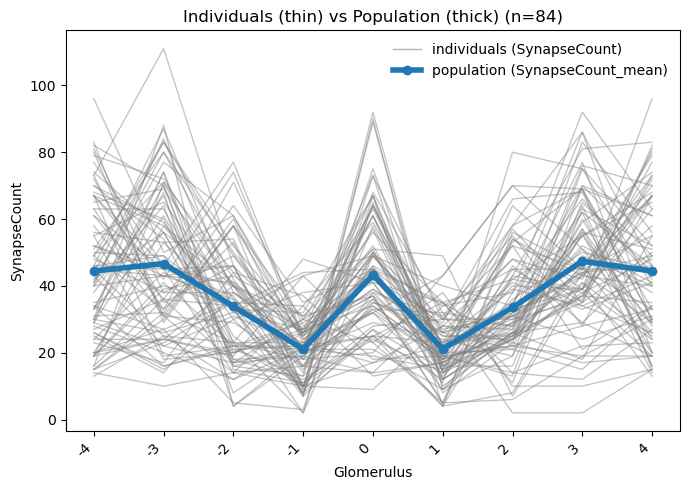

In [216]:
plot_individual_vs_population_connectome(indiv_dict=dict_all_halves_commectome,
                              pop_df=summarydf_all_halves_commectome,
                              metric="SynapseCount")

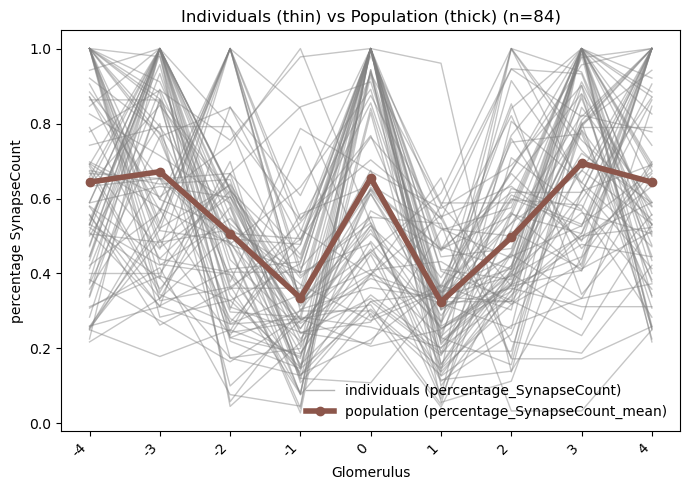

In [217]:
plot_individual_vs_population_connectome(dict_all_halves_commectome,
                              summarydf_all_halves_commectome,  "tab:brown",
                              metric="percentage_SynapseCount", mean_version="old")

In [218]:
def plot_individual_vs_population_connectome_colorful(
    indiv_dict,
    pop_df,
    line_color="tab:blue",
    title=None,
    *,
    metric="SynapseCount",          # "SynapseCount" or "percentage_SynapseCount"
    mean_version="old",             # when metric="percentage_SynapseCount": "old" or "new"
    indiv_alpha=0.35,               # transparency for individual lines
    palette=None                    # optional list of colors; default = Matplotlib prop_cycle
):
    if not indiv_dict:
        raise ValueError("indiv_dict is empty.")

    metric = str(metric)
    if metric not in {"SynapseCount", "percentage_SynapseCount"}:
        raise ValueError("metric must be 'SynapseCount' or 'percentage_SynapseCount'.")

    # pick population series based on metric + version
    if metric == "SynapseCount":
        if "SynapseCount_mean" not in pop_df.columns:
            raise ValueError("pop_df must contain 'SynapseCount_mean'.")
        y_pop_raw = pd.to_numeric(pop_df["SynapseCount_mean"], errors="coerce")
        pop_label = "population (SynapseCount_mean)"
    else:
        mean_version = str(mean_version).lower()
        if mean_version not in {"old", "new"}:
            raise ValueError("mean_version must be 'old' or 'new' when metric='percentage_SynapseCount'.")
        if mean_version == "old":
            col = "percentage_SynapseCount_mean"
            if col not in pop_df.columns:
                raise ValueError(f"pop_df must contain '{col}' for mean_version='old'.")
            y_pop_raw = pd.to_numeric(pop_df[col], errors="coerce")
            pop_label = "population (percentage_SynapseCount_mean)"
        else:
            if "percentage_SynapseCount_mean_NEW" in pop_df.columns:
                y_pop_raw = pd.to_numeric(pop_df["percentage_SynapseCount_mean_NEW"], errors="coerce")
                pop_label = "population (percentage_SynapseCount_mean_NEW)"
            else:
                if "SynapseCount_mean" not in pop_df.columns:
                    raise ValueError("pop_df must contain 'SynapseCount_mean' to compute NEW version.")
                scm = pd.to_numeric(pop_df["SynapseCount_mean"], errors="coerce")
                m = scm.max(skipna=True)
                y_pop_raw = (scm / m) if (np.isfinite(m) and m != 0) else scm * 0
                pop_label = "population (SynapseCount_mean / max)"

    # truncate to shortest length across inputs
    lengths = [len(df) for df in indiv_dict.values()]
    lengths.append(len(pop_df))
    L = int(min(lengths))

    # X tick labels
    if "glomerulus" in pop_df.columns:
        xtick_labels = pop_df["glomerulus"].astype(str).tolist()[:L]
    elif "Glomerulus" in pop_df.columns:
        xtick_labels = pop_df["Glomerulus"].astype(str).tolist()[:L]
    else:
        xtick_labels = [str(i) for i in range(L)]
    x = np.arange(L)

    # color cycle for individuals
    if palette is None:
        palette = plt.rcParams.get("axes.prop_cycle", None)
        colors = (palette.by_key().get("color", [f"C{i}" for i in range(10)])) if palette else [f"C{i}" for i in range(10)]
    else:
        colors = list(palette)
    color_iter = itertools.cycle(colors)

    plt.figure(figsize=(7, 5))

    # colorful individual lines
    for name, df in indiv_dict.items():
        if metric not in df.columns:
            raise ValueError(f"'{metric}' not found in individual df '{name}'.")
        y_ind = pd.to_numeric(df[metric], errors="coerce").to_numpy()[:L]
        plt.plot(x, y_ind, linewidth=1, alpha=indiv_alpha, color=next(color_iter))

    # proxy legend entry for individuals
    plt.plot([], [], linewidth=1.5, alpha=indiv_alpha, color="C0", label=f"individuals ({metric})")

    # thick population mean
    y_pop = y_pop_raw.to_numpy()[:L]
    plt.plot(x, y_pop, linewidth=4, color=line_color, marker="o", label=pop_label)

    plt.xticks(x, xtick_labels, rotation=45, ha="right")
    plt.xlabel("Glomerulus")
    plt.ylabel(metric.replace("_", " "))
    plt.title(title or f"Individuals (thin) vs Population (thick) (n={len(indiv_dict)})")
    plt.legend(frameon=False)   #loc="upper right", 
    plt.tight_layout()
    plt.show()

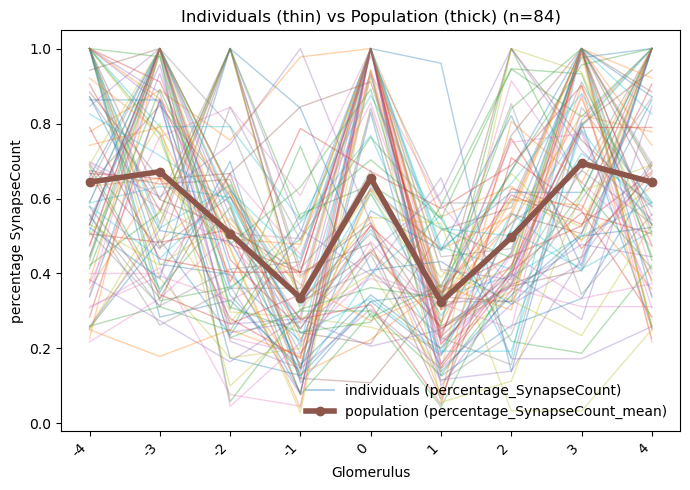

In [219]:
plot_individual_vs_population_connectome_colorful(
    dict_all_halves_commectome,
    summarydf_all_halves_commectome,
    metric="percentage_SynapseCount",
    line_color="tab:brown",
    indiv_alpha=0.35
)

<font size="10">PART TWO</font>

# glucl part

In [220]:
data_dir = Path('reordered_2glo_some3glo_halves(diffred_samegreen)')

csv_files = sorted(data_dir.glob('*.csv'))

dict_all_halves_ihc = {
    f.stem: pd.read_csv(f)
    for f in csv_files
}

for name, df in dict_all_halves_ihc.items():
    print(name, df.shape)

fly12_L_combine19_reordered_add1row (9, 5)
fly12_R_combine19_reordered_add1row (9, 5)
fly13_L_combine19_reordered_add1row (9, 5)
fly13_R_combine19_reordered_add1row (9, 5)
fly14_L_combine19_reordered_add1row (9, 5)
fly14_R_combine19_reordered_add1row (9, 5)
fly15_L_combine19_reordered_add1row (9, 5)
fly15_R_combine19_reordered_add1row (9, 5)
fly16_L_combine19_reordered_add1row (9, 5)
fly16_R_combine19_reordered_add1row (9, 5)
fly17_L_combine19_reordered_add1row (9, 5)
fly17_R_combine19_reordered_add1row (9, 5)
fly1_L_combine19_reordered_add1row (9, 5)
fly1_R_combine19_reordered_add1row (9, 5)
fly3_L_combine19_reordered_add1row (9, 5)
fly3_R_combine19_reordered_add1row (9, 5)
fly4_L_combine19_reordered_add1row (9, 5)
fly4_R_combine19_reordered_add1row (9, 5)
fly6_L_combine19_reordered_add1row (9, 5)
fly6_R_combine19_reordered_add1row (9, 5)
fly7_L_combine19_reordered_add1row (9, 5)
fly7_R_combine19_reordered_add1row (9, 5)
fly8_L_combine19_reordered_add1row (9, 5)
fly8_R_combine19_reord

In [221]:
# add the percentage column
def add_pct_of_max_total_green(
    dfs: Dict[str, pd.DataFrame],
    *,
    value_col: str = "total_green",
    new_col: str = "percentage_total_green",
    inplace: bool = False
) -> Dict[str, pd.DataFrame]:
    """
    For each DF in `dfs`, add `new_col` = DF[value_col] / max(DF[value_col]).
    If the column is missing or the max is 0/NaN, fills 0.0.
    Returns a new dict unless inplace=True (then returns the original dict).
    """
    out = dfs if inplace else {}

    for name, df in dfs.items():
        if not isinstance(df, pd.DataFrame) or df.empty or value_col not in df.columns:
            if not inplace:
                out[name] = df
            continue

        tmp = df.copy()
        s = pd.to_numeric(tmp[value_col], errors="coerce")
        m = s.max(skipna=True)

        tmp[new_col] = (s / m).astype(float) if pd.notna(m) and m != 0 else 0.0
        out[name] = tmp

    return out

In [222]:
dict_all_halves_ihc = add_pct_of_max_total_green(dict_all_halves_ihc)

In [223]:
dict_all_halves_ihc['fly12_L_combine19_reordered_add1row']

,glomerulus,mean_red,mean_green,total_red,total_green,percentage_total_green
0,L7,700.9,239.1,4.752996e+08,16043139.0,0.265285
1,L6,554.3,214.2,3.870011e+08,9527123.0,0.157538
2,L5,485.7,204.3,1.886452e+08,3764394.0,0.062247
3,L4,428.5,196.7,2.717540e+08,7088330.0,0.117211
4,L3,843.7,201.8,2.053103e+09,60475056.0,1.000000
5,L2,479.4,194.2,2.346397e+08,2245639.0,0.037133
6,L1+9,604.1,224.8,2.913234e+08,9605923.0,0.158841
7,L8,779.5,240.8,3.550039e+08,17225573.0,0.284838
8,added,700.9,239.1,4.752996e+08,16043139.0,0.265285


In [234]:
# add the two "normalized" columns

# it should be:
# "percentage_total_green" in each df in reordered_2glo_some3glo_halves_ihc (or dct) is divided by "SynapseCount_mean" in sum_2glo_some3glo_halves_d7 (or denom_d7_df) --> "percentage_total_green_divided_by_d7countall" column
# "percentage_total_green" in each df in reordered_2glo_some3glo_halves_ihc (or dct) is divided by "percentage_SynapseCount_mean" in sum_2glo_some3glo_halves_d7 (or denom_d7_df) --> "percentage_total_green_divided_by_d7%all" column


def add_normalized_columns_to_halves(
    dct: dict,
    denom_d7_df: pd.DataFrame,
    *,
    value_col: str = "percentage_total_green",
    denom_glut_df: pd.DataFrame | None = None,   # optional: adds the two glutamate-based columns
    inplace: bool = True,
):
    """
    For each DataFrame in `dct`, add:
      D7-based:
        - 'total_green_divided_by_d7countall' = value_col / denom_d7_df['SynapseCount_mean']
        - 'total_green_divided_by_d7%all'     = value_col / denom_d7_df['percentage_SynapseCount_mean']

      (Optional) Glutamate-based (if denom_glut_df is provided):
        - 'total_green_divided_by_glutamatecountall' = value_col / denom_glut_df['SynapseCount_mean']
        - 'total_green_divided_by_glutamate%all'     = value_col / denom_glut_df['percentage_SynapseCount_mean']

    Division is aligned by row index; denom zeros/NaNs yield NaN (safe divide).
    """

    # --- required D7 denominators ---
    for needed in ("SynapseCount_mean", "percentage_SynapseCount_mean"):
        if needed not in denom_d7_df.columns:
            raise ValueError(f"denom_d7_df must have '{needed}' column.")

    d7_count = pd.to_numeric(denom_d7_df["SynapseCount_mean"], errors="coerce").reset_index(drop=True)
    d7_pct   = pd.to_numeric(denom_d7_df["percentage_SynapseCount_mean"], errors="coerce").reset_index(drop=True)

    # --- optional glutamate denominators (both columns required if provided) ---
    glut_count = glut_pct = None
    if denom_glut_df is not None:
        for needed in ("SynapseCount_mean", "percentage_SynapseCount_mean"):
            if needed not in denom_glut_df.columns:
                raise ValueError(f"denom_glut_df must have '{needed}' column.")
        glut_count = pd.to_numeric(denom_glut_df["SynapseCount_mean"], errors="coerce").reset_index(drop=True)
        glut_pct   = pd.to_numeric(denom_glut_df["percentage_SynapseCount_mean"], errors="coerce").reset_index(drop=True)

    out_dict = dct if inplace else {}

    for name, df in dct.items():
        if value_col not in df.columns:
            continue

        tmp = df.copy()
        num = pd.to_numeric(tmp[value_col], errors="coerce").reset_index(drop=True)

        # --- divide by D7 SynapseCount_mean ---
        n = min(len(num), len(d7_count))
        res_d7_count = np.divide(
            num.iloc[:n].to_numpy(), d7_count.iloc[:n].to_numpy(),
            out=np.full(n, np.nan, dtype=float),
            where=(d7_count.iloc[:n].to_numpy() != 0) & np.isfinite(d7_count.iloc[:n].to_numpy())
        )
        tmp["percentage_total_green_divided_by_d7countall"] = np.nan
        tmp.loc[tmp.index[:n], "percentage_total_green_divided_by_d7countall"] = res_d7_count

        # --- divide by D7 percentage_SynapseCount_mean ---
        m = min(len(num), len(d7_pct))
        res_d7_pct = np.divide(
            num.iloc[:m].to_numpy(), d7_pct.iloc[:m].to_numpy(),
            out=np.full(m, np.nan, dtype=float),
            where=(d7_pct.iloc[:m].to_numpy() != 0) & np.isfinite(d7_pct.iloc[:m].to_numpy())
        )
        tmp["percentage_total_green_divided_by_d7%all"] = np.nan
        tmp.loc[tmp.index[:m], "percentage_total_green_divided_by_d7%all"] = res_d7_pct

        # --- optional glutamate: compute BOTH analogous columns ---
        if (glut_count is not None) and (glut_pct is not None):
            k = min(len(num), len(glut_count))
            res_glut_count = np.divide(
                num.iloc[:k].to_numpy(), glut_count.iloc[:k].to_numpy(),
                out=np.full(k, np.nan, dtype=float),
                where=(glut_count.iloc[:k].to_numpy() != 0) & np.isfinite(glut_count.iloc[:k].to_numpy())
            )
            tmp["total_green_divided_by_glutamatecountall"] = np.nan
            tmp.loc[tmp.index[:k], "total_green_divided_by_glutamatecountall"] = res_glut_count

            r = min(len(num), len(glut_pct))
            res_glut_pct = np.divide(
                num.iloc[:r].to_numpy(), glut_pct.iloc[:r].to_numpy(),
                out=np.full(r, np.nan, dtype=float),
                where=(glut_pct.iloc[:r].to_numpy() != 0) & np.isfinite(glut_pct.iloc[:r].to_numpy())
            )
            tmp["total_green_divided_by_glutamate%all"] = np.nan
            tmp.loc[tmp.index[:r], "total_green_divided_by_glutamate%all"] = res_glut_pct

        out_dict[name] = tmp

    return out_dict if not inplace else None

In [237]:
add_normalized_columns_to_halves(
    dict_all_halves_ihc,
    denom_d7_df=summarydf_all_halves_commectome,
    #denom_glut_df=sum_2glo_some3glo_halves_glutamate,
    value_col="percentage_total_green",
    inplace=True
)

In [238]:
dict_all_halves_ihc['fly12_L_combine19_reordered_add1row']

,glomerulus,mean_red,mean_green,total_red,total_green,percentage_total_green,percentage_total_green_divided_by_d7countall,percentage_total_green_divided_by_d7%all
0,L7,700.9,239.1,4.752996e+08,16043139.0,0.265285,0.005969,0.412090
1,L6,554.3,214.2,3.870011e+08,9527123.0,0.157538,0.003376,0.234576
2,L5,485.7,204.3,1.886452e+08,3764394.0,0.062247,0.001838,0.122899
3,L4,428.5,196.7,2.717540e+08,7088330.0,0.117211,0.005566,0.350324
4,L3,843.7,201.8,2.053103e+09,60475056.0,1.000000,0.023083,1.528318
5,L2,479.4,194.2,2.346397e+08,2245639.0,0.037133,0.001758,0.114506
6,L1+9,604.1,224.8,2.913234e+08,9605923.0,0.158841,0.004736,0.320094
7,L8,779.5,240.8,3.550039e+08,17225573.0,0.284838,0.006013,0.410253
8,added,700.9,239.1,4.752996e+08,16043139.0,0.265285,0.005969,0.412090


In [239]:
# create the summary df of the glucl(IHC) dfs

def build_population_df(
    dfs: Dict[str, pd.DataFrame],
    *,
    cols: Optional[List[str]] = None,
    avg_cols: Optional[List[str]] = None,
    n_positions: int = 9
) -> pd.DataFrame:
    """
    Collect 9-row numeric slices from each DF in `dfs`, sum them position-wise,
    then append averages for selected columns.

    Returns a DataFrame with a 'glomerulus' column set to [-4..4].
    """
    if cols is None:
        cols = [
            "mean_red", "mean_green", "total_red", "total_green",
            "percentage_total_green",
            "percentage_total_green_divided_by_d7countall",
            "percentage_total_green_divided_by_d7%all",
            #"percentage_total_green_divided_by_d7countsubtype",
            #"percentage_total_green_divided_by_d7%subtype",
        ]

    if avg_cols is None:
        avg_cols = [
            "total_green",
            "percentage_total_green",
            "percentage_total_green_divided_by_d7countall",
            "percentage_total_green_divided_by_d7%all",
            #"percentage_total_green_divided_by_d7countsubtype",
            #"percentage_total_green_divided_by_d7%subtype",
        ]

    # collect cleaned slices
    stack = []
    for _, df in dfs.items():
        if not isinstance(df, pd.DataFrame) or df.empty:
            continue
        # ensure requested columns exist; missing -> NaN -> later 0
        tmp = (
            df.reindex(columns=cols)
              .apply(pd.to_numeric, errors="coerce")
              .reset_index(drop=True)
              .reindex(range(n_positions))
              .fillna(0)
        )
        stack.append(tmp)

    n_inputs = len(stack)

    if n_inputs == 0:
        pop = pd.DataFrame(0, index=range(n_positions), columns=cols)
    else:
        pop = (
            pd.concat(stack, keys=range(n_inputs))
              .groupby(level=1)
              .sum()
              .reindex(range(n_positions), fill_value=0)
        )

    # add position column on the left: -4..4 (assumes n_positions == 9)
    if n_positions == 9:
        gloms = list(range(-4, 5))
    else:
        # symmetric range centered at 0
        half = n_positions // 2
        gloms = list(range(-half, n_positions - half))
    pop.insert(0, "glomerulus", gloms)

    # add averages
    if n_inputs > 0:
        for c in avg_cols:
            if c in pop.columns:
                pop[f"{c}_avg"] = pop[c] / n_inputs
    else:
        # still create the columns for consistency, filled with NaN
        for c in avg_cols:
            pop[f"{c}_avg"] = np.nan

    return pop

In [240]:
summarydf_all_halves_ihc = build_population_df(dict_all_halves_ihc)
summarydf_all_halves_ihc

,glomerulus,mean_red,mean_green,total_red,total_green,percentage_total_green,percentage_total_green_divided_by_d7countall,percentage_total_green_divided_by_d7%all,total_green_avg,percentage_total_green_avg,percentage_total_green_divided_by_d7countall_avg,percentage_total_green_divided_by_d7%all_avg
0,-4,17500.017696,5860.313037,1.623735e+10,1.128170e+09,6.526031,0.146849,10.137437,4.700709e+07,0.271918,0.006119,0.422393
1,-3,15844.203337,5633.673361,1.550587e+10,1.081626e+09,6.138868,0.131547,9.140853,4.506776e+07,0.255786,0.005481,0.380869
2,-2,13552.040376,5480.262333,1.078569e+10,7.705925e+08,4.261698,0.125829,8.414223,3.210802e+07,0.177571,0.005243,0.350593
3,-1,12912.039708,5240.267326,7.555939e+09,5.205232e+08,2.835668,0.134650,8.475356,2.168847e+07,0.118153,0.005610,0.353140
4,0,29055.276110,6467.243970,5.983264e+10,4.155966e+09,24.000000,0.553998,36.679635,1.731652e+08,1.000000,0.023083,1.528318
5,1,14139.298168,5429.307910,8.720132e+09,4.882501e+08,2.760540,0.130713,8.512495,2.034375e+07,0.115022,0.005446,0.354687
6,2,16646.467416,5972.555194,1.273110e+10,9.532534e+08,5.426323,0.161807,10.935027,3.971889e+07,0.226097,0.006742,0.455626
7,3,17753.040468,6254.294274,1.520261e+10,1.074362e+09,6.332541,0.133685,9.120794,4.476508e+07,0.263856,0.005570,0.380033
8,4,17500.017696,5860.313037,1.623735e+10,1.128170e+09,6.526031,0.146849,10.137437,4.700709e+07,0.271918,0.006119,0.422393


In [229]:
# this cell plots both the individual data (in thin grey lines) and the population data (in colored thicker line).


def plot_individual_vs_population_ihc(indiv_dict, pop_df, metric="mean", channel="green", line_color=None):
    """
    Plot all individual data (thin gray lines) and the population average (thick colored line).

    indiv_dict : dict of DataFrames
        Each DataFrame must contain a column named f"{metric}_{channel}".
    pop_df : DataFrame
        Must contain columns f"{metric}_{channel}" and f"{metric}_{channel}_avg".
    metric : str, default "mean"
        The metric to use ("mean" or "total").
    channel : str, default "green"
        The channel name ("green" or "red").
    line_color : str, optional
        Color for the population line. If None, use the channel name.
    """
    signal = f"{metric}_{channel}"
    signal_avg = f"{metric}_{channel}_avg"
    line_color = line_color or channel  # default: "green" -> green line, "red" -> red line

    # lengths
    lens = [len(df) for df in indiv_dict.values()]
    lens.append(len(pop_df))
    L = min(lens)  # common length

    x = np.arange(L)

    plt.figure(figsize=(7, 5))

    # thin lines for individuals
    for name, df in indiv_dict.items():
        y = pd.to_numeric(df[signal], errors="coerce").to_numpy()[:L]
        plt.plot(x, y, linewidth=1, alpha=0.45, color="gray")

    # proxy line for legend
    plt.plot([], [], linewidth=1, color="gray", alpha=0.6, label=f"individuals ({signal})")

    # population line
    y_pop = pd.to_numeric(pop_df[signal_avg], errors="coerce").to_numpy()[:L]
    plt.plot(x, y_pop, linewidth=4, color=line_color, marker="o", label=f"population ({signal_avg})")

    # x-axis labels
    if "glomerulus" in pop_df.columns:
        xtick_labels = pop_df["glomerulus"].astype(str).tolist()[:L]
    else:
        xtick_labels = [str(i) for i in range(L)]

    plt.xticks(x, xtick_labels)
    plt.xlabel("Glomerulus")
    plt.ylabel(signal.replace("_", " "))
    #plt.title(f"Individuals (thin) vs Population (thick) (n={len(indiv_dict)})")
    #plt.legend(frameon=False)
    #plt.tight_layout()
    plt.title(f"Individuals (thin) vs Population (thick) (n={len(indiv_dict)})", pad=20)
    plt.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.07), ncol=2, borderaxespad=0.0)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

In [230]:
def plot_individual_vs_population_ihc_nolegend(
    indiv_dict, pop_df, metric="mean", channel="green", line_color=None,
    show_legend: bool = True  # <-- NEW
):
    """
    Plot all individual data (thin gray lines) and the population average (thick colored line).

    show_legend : bool, default True
        If False, don’t draw a legend (and don’t reserve extra top space).
    """
    signal = f"{metric}_{channel}"
    signal_avg = f"{metric}_{channel}_avg"
    line_color = line_color or channel  # default: "green" -> green line, "red" -> red line

    # lengths
    lens = [len(df) for df in indiv_dict.values()]
    lens.append(len(pop_df))
    L = min(lens)  # common length

    x = np.arange(L)

    plt.figure(figsize=(7, 5))

    # thin lines for individuals
    for name, df in indiv_dict.items():
        y = pd.to_numeric(df[signal], errors="coerce").to_numpy()[:L]
        plt.plot(x, y, linewidth=1, alpha=0.45, color="gray")

    # proxy line only if showing legend
    if show_legend:  # <-- CHANGED
        plt.plot([], [], linewidth=1, color="gray", alpha=0.6, label=f"individuals ({signal})")

    # population line
    y_pop = pd.to_numeric(pop_df[signal_avg], errors="coerce").to_numpy()[:L]
    plt.plot(x, y_pop, linewidth=4, color=line_color, marker="o",
             label=(f"population ({signal_avg})" if show_legend else None))  # <-- CHANGED

    # x-axis labels
    if "glomerulus" in pop_df.columns:
        xtick_labels = pop_df["glomerulus"].astype(str).tolist()[:L]
    else:
        xtick_labels = [str(i) for i in range(L)]

    plt.xticks(x, xtick_labels)
    plt.xlabel("Glomerulus")
    plt.ylabel(signal.replace("_", " "))
    plt.title(f"Individuals (thin) vs Population (thick) (n={len(indiv_dict)})", pad=20)

    if show_legend:  # <-- CHANGED
        plt.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.07), ncol=2, borderaxespad=0.0)
        plt.tight_layout(rect=[0, 0, 1, 0.92])  # leave room for legend
    else:
        plt.tight_layout()

    plt.show()

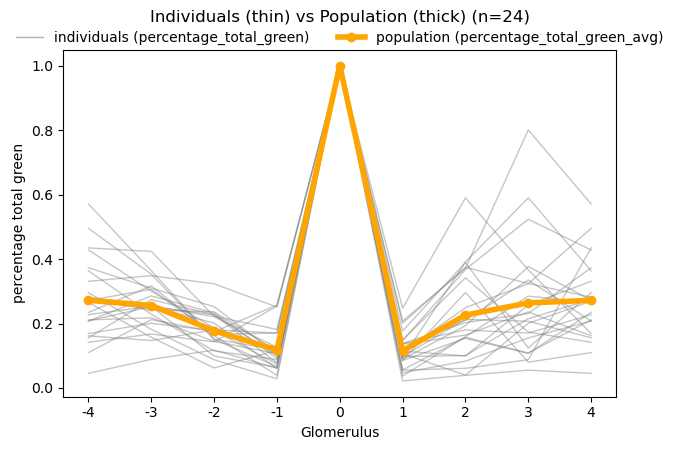

In [ ]:
plot_individual_vs_population_ihc(dict_all_halves_ihc, 
                              summarydf_all_halves_ihc, 
                              metric="percentage", channel="total_green", line_color='orange')

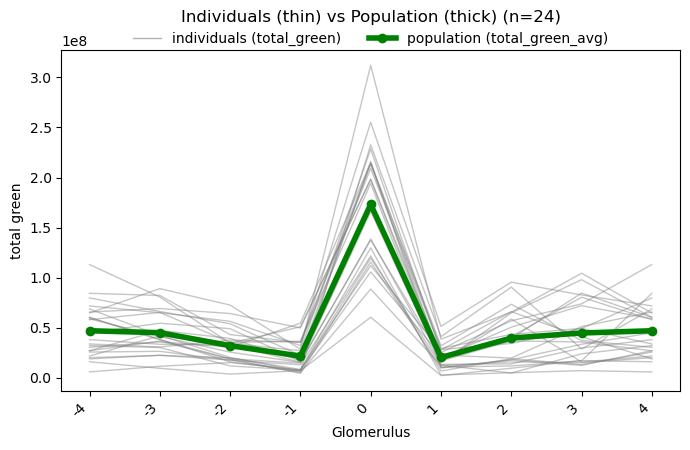

In [ ]:
plot_individual_vs_population_ihc(dict_all_halves_ihc, 
                              summarydf_all_halves_ihc, 
                              metric="total", channel="green", line_color='green')

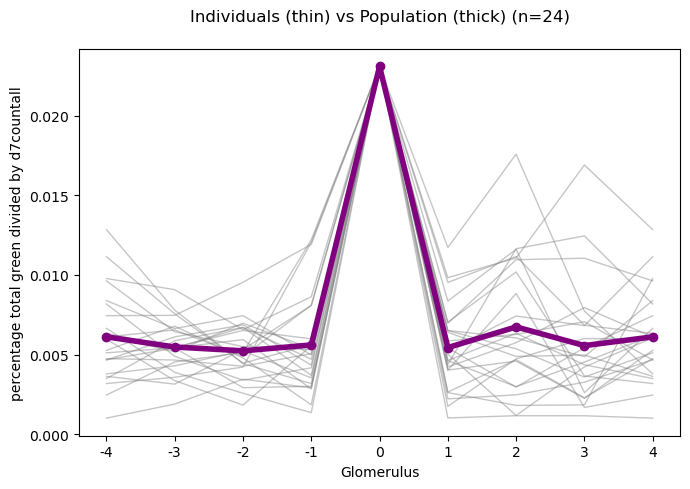

In [ ]:
plot_individual_vs_population_ihc_nolegend(dict_all_halves_ihc, summarydf_all_halves_ihc,
                                  metric="percentage", channel="total_green_divided_by_d7countall", line_color='purple',
                                  show_legend=False)

<font size="10">PART THREE</font>

# save the plot as svg

# individual lines + population line

In [ ]:
def plot_individual_vs_population_ihc_savesvg(
    indiv_dict,
    pop_df,
    metric="mean",
    channel="green",
    line_color=None,
    save_svg: str | Path | None = None,   # (existing) optional output path
    xlabel: str | None = None,            # --- NEW
    ylabel: str | None = None,            # --- NEW
    title:  str | None = None             # --- NEW (optional)
):
    """
    Plot all individual data (thin gray lines) and the population average (thick colored line).
    If `save_svg` is provided, saves an SVG to that path.
    """
    signal = f"{metric}_{channel}"
    signal_avg = f"{metric}_{channel}_avg"
    line_color = line_color or channel

    lens = [len(df) for df in indiv_dict.values()]
    lens.append(len(pop_df))
    L = min(lens)
    x = np.arange(L)

    with mpl.rc_context({"svg.fonttype": "none"}):  # keep text editable in SVG
        fig, ax = plt.subplots(figsize=(7, 5))

        # thin lines for individuals
        for _, df in indiv_dict.items():
            y = pd.to_numeric(df[signal], errors="coerce").to_numpy()[:L]
            ax.plot(x, y, linewidth=1, alpha=0.45, color="gray")

        # proxy line for legend
        ax.plot([], [], linewidth=1, color="gray", alpha=0.6, label=f"individuals ({signal})")

        # population line
        y_pop = pd.to_numeric(pop_df[signal_avg], errors="coerce").to_numpy()[:L]
        ax.plot(x, y_pop, linewidth=4, color=line_color, marker="o", label=f"population ({signal_avg})")

        # x-axis tick labels
        if "glomerulus" in pop_df.columns:
            xtick_labels = pop_df["glomerulus"].astype(str).tolist()[:L]
        else:
            xtick_labels = [str(i) for i in range(L)]
        ax.set_xticks(x)
        ax.set_xticklabels(xtick_labels)

        # --- CHANGED: customizable axis labels and title
        ax.set_xlabel(xlabel if xlabel is not None else "Glomerulus")                 # NEW
        ax.set_ylabel(ylabel if ylabel is not None else signal.replace("_", " "))     # NEW
        ax.set_title(title if title is not None else                                  
                     f"Individuals (thin) vs Population (thick) (n={len(indiv_dict)})",
                     pad=20)                                                          # NEW

        # legend under title
        ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.07), ncol=2, borderaxespad=0.0)

        fig.tight_layout(rect=[0, 0, 1, 0.92])

        # save as SVG if requested
        if save_svg is not None:
            save_svg = Path(save_svg)
            fig.savefig(
                save_svg,
                format="svg",
                bbox_inches="tight",
                transparent=True,
                metadata={"Creator": "plot_individual_vs_population"}
            )

        plt.show()

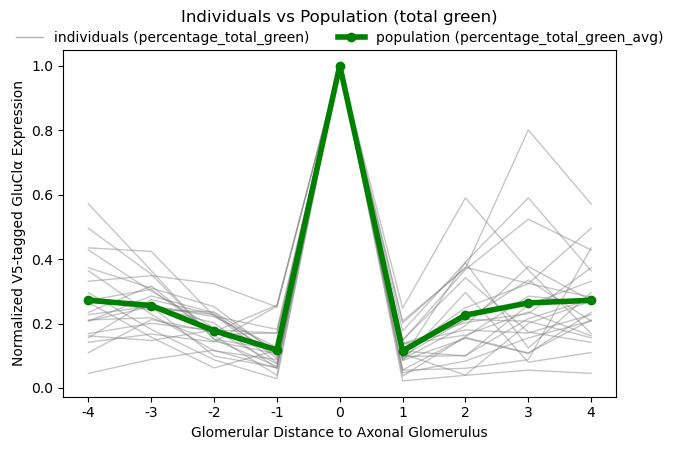

In [ ]:
plot_individual_vs_population_ihc_savesvg(
    dict_all_halves_commectome,
    summarydf_all_halves_commectome,
    metric="percentage",
    channel="total_green",
    line_color="green",
    xlabel="Glomerular Distance to Axonal Glomerulus",
    ylabel="Normalized V5-tagged GluClα Expression",
    title="Individuals vs Population (total green)",
    save_svg="glucl_individual_and_population.svg"
)

In [184]:
def plot_individual_vs_population_ihc_nolegend_savesvg(
    indiv_dict,
    pop_df,
    metric="mean",
    channel="green",
    line_color=None,
    show_legend: bool = True,                 # toggle legend
    save_svg: str | Path | None = None,       # NEW: optional SVG path
    xlabel: str | None = None,                # NEW: custom x-axis label
    ylabel: str | None = None                 # NEW: custom y-axis label
):
    """
    Plot all individual data (thin gray lines) and the population average (thick colored line).
    If `save_svg` is provided, saves an SVG to that path.
    """
    signal = f"{metric}_{channel}"
    signal_avg = f"{metric}_{channel}_avg"
    line_color = line_color or channel  # default: "green" -> green line, "red" -> red line

    # lengths
    lens = [len(df) for df in indiv_dict.values()]
    lens.append(len(pop_df))
    L = min(lens)  # common length

    x = np.arange(L)

    with mpl.rc_context({"svg.fonttype": "none"}):  # keep text editable in SVGs
        fig, ax = plt.subplots(figsize=(7, 5))

        # thin lines for individuals
        for name, df in indiv_dict.items():
            y = pd.to_numeric(df[signal], errors="coerce").to_numpy()[:L]
            ax.plot(x, y, linewidth=1, alpha=0.45, color="gray")

        # proxy line for legend (only if showing legend)
        if show_legend:
            ax.plot([], [], linewidth=1, color="gray", alpha=0.6, label=f"individuals ({signal})")

        # population line
        y_pop = pd.to_numeric(pop_df[signal_avg], errors="coerce").to_numpy()[:L]
        ax.plot(
            x, y_pop, linewidth=4, color=line_color, marker="o",
            label=(f"population ({signal_avg})" if show_legend else None)
        )

        # x-axis labels
        if "glomerulus" in pop_df.columns:
            xtick_labels = pop_df["glomerulus"].astype(str).tolist()[:L]
        else:
            xtick_labels = [str(i) for i in range(L)]
        ax.set_xticks(x)
        ax.set_xticklabels(xtick_labels)

        # axis titles (customizable)
        ax.set_xlabel(xlabel if xlabel is not None else "Glomerulus")
        ax.set_ylabel(ylabel if ylabel is not None else signal.replace("_", " "))

        ax.set_title(f"Individuals (thin) vs Population (thick) (n={len(indiv_dict)})", pad=20)

        if show_legend:
            ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.07), ncol=2, borderaxespad=0.0)
            fig.tight_layout(rect=[0, 0, 1, 0.92])  # leave room for legend
        else:
            fig.tight_layout()

        # save as SVG if requested
        if save_svg is not None:
            save_svg = Path(save_svg)
            save_svg.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(
                save_svg,
                format="svg",
                bbox_inches="tight",
                transparent=True,
                metadata={"Creator": "plot_individual_vs_population_ihc"}
            )

        plt.show()

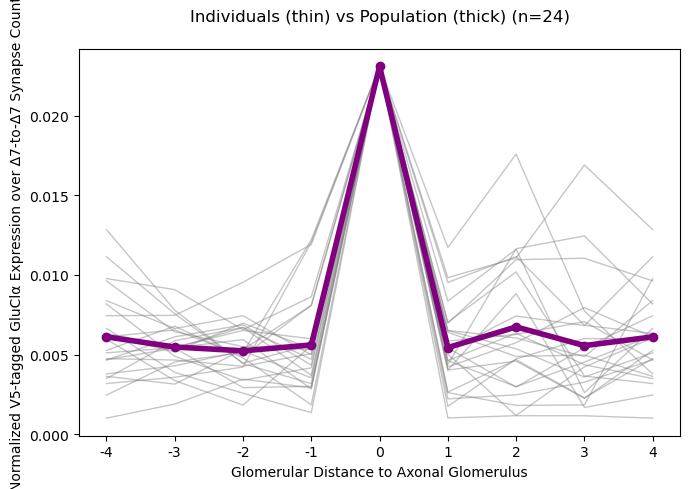

In [ ]:
plot_individual_vs_population_ihc_nolegend_savesvg(
    indiv_dict=dict_all_halves_ihc,
    pop_df=summarydf_all_halves_ihc,
    metric="percentage", channel="total_green_divided_by_d7countall", line_color="purple",
    show_legend=False,
    xlabel="Glomerular Distance to Axonal Glomerulus",
    ylabel="Normalized V5-tagged GluClα Expression over ∆7-to-∆7 Synapse Count",
    save_svg="glucl_over_connectome_individual_and_population.svg"
)

In [173]:
def plot_individual_vs_population_connectome_savesvg(
    indiv_dict,
    pop_df,
    line_color="tab:blue",
    title=None,
    *,
    metric="SynapseCount",                  # "SynapseCount" or "percentage_SynapseCount"
    mean_version="old",                     # when metric is percentage: "old" or "new"
    save_svg: str | Path | None = None,     # NEW: optional SVG output path
    xlabel: str | None = None,              # NEW: custom x-axis label
    ylabel: str | None = None               # NEW: custom y-axis label
):
    """
    Plot individual traces (thin gray) and population mean (thick colored).
    If `save_svg` is provided, saves an SVG to that path.
    """
    if not indiv_dict:
        raise ValueError("indiv_dict is empty.")
    metric = str(metric)
    if metric not in {"SynapseCount", "percentage_SynapseCount"}:
        raise ValueError("metric must be 'SynapseCount' or 'percentage_SynapseCount'.")

    # figure out population column to use
    if metric == "SynapseCount":
        pop_col = "SynapseCount_mean"
        if pop_col not in pop_df.columns:
            raise ValueError(f"pop_df must contain '{pop_col}'.")
        y_pop_raw = pd.to_numeric(pop_df[pop_col], errors="coerce")
        pop_label = "population (SynapseCount_mean)"
    else:
        mean_version = str(mean_version).lower()
        if mean_version not in {"old", "new"}:
            raise ValueError("mean_version must be 'old' or 'new' when metric='percentage_SynapseCount'.")
        if mean_version == "old":
            pop_col = "percentage_SynapseCount_mean"
            if pop_col not in pop_df.columns:
                raise ValueError(f"pop_df must contain '{pop_col}' for mean_version='old'.")
            y_pop_raw = pd.to_numeric(pop_df[pop_col], errors="coerce")
            pop_label = "population (percentage_SynapseCount_mean)"
        else:
            if "percentage_SynapseCount_mean_NEW" in pop_df.columns:
                y_pop_raw = pd.to_numeric(pop_df["percentage_SynapseCount_mean_NEW"], errors="coerce")
                pop_label = "population (percentage_SynapseCount_mean_NEW)"
            else:
                if "SynapseCount_mean" not in pop_df.columns:
                    raise ValueError("pop_df must contain 'SynapseCount_mean' to compute NEW version.")
                scm = pd.to_numeric(pop_df["SynapseCount_mean"], errors="coerce")
                m = scm.max(skipna=True)
                y_pop_raw = (scm / m) if (np.isfinite(m) and m != 0) else scm * 0
                pop_label = "population (SynapseCount_mean / max)"

    # Common length (truncate to shortest)
    lengths = [len(df) for df in indiv_dict.values()]
    lengths.append(len(pop_df))
    L = int(min(lengths))

    # X axis labels
    if "glomerulus" in pop_df.columns:
        xtick_labels = pop_df["glomerulus"].astype(str).tolist()[:L]
    elif "Glomerulus" in pop_df.columns:
        xtick_labels = pop_df["Glomerulus"].astype(str).tolist()[:L]
    else:
        xtick_labels = [str(i) for i in range(L)]
    x = np.arange(L)

    with mpl.rc_context({"svg.fonttype": "none"}):  # keep text editable in SVG
        fig, ax = plt.subplots(figsize=(7, 5))

        # Thin individual lines
        for name, df in indiv_dict.items():
            if metric not in df.columns:
                raise ValueError(f"'{metric}' not found in individual df '{name}'.")
            y_ind = pd.to_numeric(df[metric], errors="coerce").to_numpy()[:L]
            ax.plot(x, y_ind, linewidth=1, alpha=0.45, color="gray")

        # Proxy legend entry for individuals
        ax.plot([], [], linewidth=1, color="gray", alpha=0.6, label=f"individuals ({metric})")

        # Thick population line
        y_pop = y_pop_raw.to_numpy()[:L]
        ax.plot(x, y_pop, linewidth=4, color=line_color, marker="o", label=pop_label)

        ax.set_xticks(x)
        ax.set_xticklabels(xtick_labels)

        ax.set_xlabel(xlabel if xlabel is not None else "Glomerulus")                    # NEW
        ax.set_ylabel(ylabel if ylabel is not None else metric.replace("_", " "))        # NEW
        ax.set_title(title or f"Individuals (thin) vs Population (thick) (n={len(indiv_dict)})")

        ax.legend(frameon=False)
        fig.tight_layout()

        # Save as SVG if requested
        if save_svg is not None:
            save_svg = Path(save_svg)
            save_svg.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(
                save_svg,
                format="svg",
                bbox_inches="tight",
                transparent=True,
                metadata={"Creator": "plot_individual_vs_population"}
            )
        plt.show()

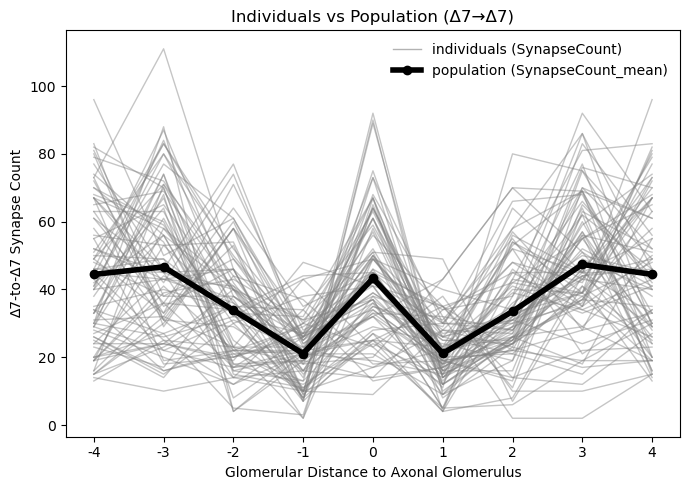

In [ ]:
plot_individual_vs_population_connectome_savesvg(
    indiv_dict=dict_all_halves_commectome,
    pop_df=summarydf_all_halves_commectome,
    metric="SynapseCount",
    line_color="black",
    xlabel="Glomerular Distance to Axonal Glomerulus",
    ylabel="∆7-to-∆7 Synapse Count",
    title="Individuals vs Population (Δ7→Δ7)",
    save_svg="connectome_individual_and_population.svg"
)

# population line only

In [161]:
def plot_line_svg(
    df: pd.DataFrame,
    y_col: str,
    *,
    x_col: str = "glomerulus",
    filename: str = "line.svg",
    line_color: str | None = None,
    marker: str = "o",
    figsize=(6, 4),
    xlabel: str | None = None,   # <-- NEW: custom x-axis title
    ylabel: str | None = None,   # <-- NEW: custom y-axis title
    title: str | None = None,    # optional custom plot title
    show_legend: bool = True
) -> str:
    """
    Plot a single series y_col vs x_col and save as an SVG.
    You can override axis titles via `xlabel` and `ylabel`.
    Returns the output filename (string path).
    """
    if y_col not in df.columns:
        raise ValueError(f"Column '{y_col}' not found in DataFrame.")

    # y values (numeric)
    y = pd.to_numeric(df[y_col], errors="coerce").to_numpy(dtype=float)

    # x values (numeric if possible, else fall back to index)
    if x_col in df.columns:
        x_num = pd.to_numeric(df[x_col], errors="coerce")
        x = (x_num.to_numpy(dtype=float)
             if x_num.notna().any()
             else np.arange(len(df), dtype=float))
        x_name = x_col
    else:
        x = np.arange(len(df), dtype=float)
        x_name = "index"

    used = np.isfinite(x) & np.isfinite(y)

    with mpl.rc_context({"svg.fonttype": "none"}):  # keep text editable in SVG
        fig, ax = plt.subplots(figsize=figsize)
        ax.plot(x[used], y[used], marker=marker, linestyle="-",
                linewidth=2, color=line_color or "black", label=y_col)

        # Axis titles (fallbacks if not provided)
        ax.set_xlabel(xlabel if xlabel is not None else x_name)
        ax.set_ylabel(ylabel if ylabel is not None else y_col.replace("_", " "))

        # Title
        ax.set_title(title if title is not None else f"{y_col} vs {x_name}")

        if show_legend:
            ax.legend(frameon=False)

        fig.tight_layout()

        out = Path(filename)
        out.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out, format="svg", bbox_inches="tight", transparent=True,
                    metadata={"Creator": "plot_line_svg"})
        plt.close(fig)

    return str(out)

In [ ]:
plot_line_svg(
    summarydf_all_halves_commectome,
    y_col="SynapseCount",
    x_col="glomerulus",
    filename="connectome_population_only.svg",
    line_color="black",
    xlabel="Glomerular Distance to Axonal Glomerulus",
    ylabel="∆7-to-∆7 Synapse Count",
    title="Δ7→Δ7 synapse count per PB position"
)

'connectome_population_only.svg'

In [ ]:
summarydf_all_halves_commectome

,glomerulus,SynapseCount,SynapseCount_mean,percentage_SynapseCount,percentage_SynapseCount_mean,percentage_SynapseCount_mean_NEW
0,-4,3733,44.440476,54.075465,0.643756,0.938175
1,-3,3920,46.666667,56.413211,0.671586,0.985172
2,-2,2845,33.869048,42.544946,0.506487,0.715004
3,-1,1769,21.059524,28.104556,0.334578,0.444584
4,0,3639,43.321429,54.962380,0.654314,0.914551
5,1,1774,21.119048,27.240587,0.324293,0.445841
6,2,2817,33.535714,41.683586,0.496233,0.707967
7,3,3979,47.369048,58.320960,0.694297,1.000000
8,4,3733,44.440476,54.075465,0.643756,0.938175


In [ ]:
summarydf_all_halves_ihc

,glomerulus,mean_red,mean_green,total_red,total_green,percentage_total_green,percentage_total_green_divided_by_d7countall,percentage_total_green_divided_by_d7%all,total_green_avg,percentage_total_green_avg,percentage_total_green_divided_by_d7countall_avg,percentage_total_green_divided_by_d7%all_avg
0,-4,17500.017696,5860.313037,1.623735e+10,1.128170e+09,6.526031,0.146849,10.137437,4.700709e+07,0.271918,0.006119,0.422393
1,-3,15844.203337,5633.673361,1.550587e+10,1.081626e+09,6.138868,0.131547,9.140853,4.506776e+07,0.255786,0.005481,0.380869
2,-2,13552.040376,5480.262333,1.078569e+10,7.705925e+08,4.261698,0.125829,8.414223,3.210802e+07,0.177571,0.005243,0.350593
3,-1,12912.039708,5240.267326,7.555939e+09,5.205232e+08,2.835668,0.134650,8.475356,2.168847e+07,0.118153,0.005610,0.353140
4,0,29055.276110,6467.243970,5.983264e+10,4.155966e+09,24.000000,0.553998,36.679635,1.731652e+08,1.000000,0.023083,1.528318
5,1,14139.298168,5429.307910,8.720132e+09,4.882501e+08,2.760540,0.130713,8.512495,2.034375e+07,0.115022,0.005446,0.354687
6,2,16646.467416,5972.555194,1.273110e+10,9.532534e+08,5.426323,0.161807,10.935027,3.971889e+07,0.226097,0.006742,0.455626
7,3,17753.040468,6254.294274,1.520261e+10,1.074362e+09,6.332541,0.133685,9.120794,4.476508e+07,0.263856,0.005570,0.380033
8,4,17500.017696,5860.313037,1.623735e+10,1.128170e+09,6.526031,0.146849,10.137437,4.700709e+07,0.271918,0.006119,0.422393


<font size="10">PART FOUR</font>

# cosine fit

In [241]:
summarydf_all_halves_ihc

,glomerulus,mean_red,mean_green,total_red,total_green,percentage_total_green,percentage_total_green_divided_by_d7countall,percentage_total_green_divided_by_d7%all,total_green_avg,percentage_total_green_avg,percentage_total_green_divided_by_d7countall_avg,percentage_total_green_divided_by_d7%all_avg
0,-4,17500.017696,5860.313037,1.623735e+10,1.128170e+09,6.526031,0.146849,10.137437,4.700709e+07,0.271918,0.006119,0.422393
1,-3,15844.203337,5633.673361,1.550587e+10,1.081626e+09,6.138868,0.131547,9.140853,4.506776e+07,0.255786,0.005481,0.380869
2,-2,13552.040376,5480.262333,1.078569e+10,7.705925e+08,4.261698,0.125829,8.414223,3.210802e+07,0.177571,0.005243,0.350593
3,-1,12912.039708,5240.267326,7.555939e+09,5.205232e+08,2.835668,0.134650,8.475356,2.168847e+07,0.118153,0.005610,0.353140
4,0,29055.276110,6467.243970,5.983264e+10,4.155966e+09,24.000000,0.553998,36.679635,1.731652e+08,1.000000,0.023083,1.528318
5,1,14139.298168,5429.307910,8.720132e+09,4.882501e+08,2.760540,0.130713,8.512495,2.034375e+07,0.115022,0.005446,0.354687
6,2,16646.467416,5972.555194,1.273110e+10,9.532534e+08,5.426323,0.161807,10.935027,3.971889e+07,0.226097,0.006742,0.455626
7,3,17753.040468,6254.294274,1.520261e+10,1.074362e+09,6.332541,0.133685,9.120794,4.476508e+07,0.263856,0.005570,0.380033
8,4,17500.017696,5860.313037,1.623735e+10,1.128170e+09,6.526031,0.146849,10.137437,4.700709e+07,0.271918,0.006119,0.422393


In [139]:
# ---- model
def cos_model(x, A, T, phi, B):                                      # the np.cos is the built-in part.
    return A * np.cos(2*np.pi/T * (x - phi)) + B

# ---- metrics (NaN-safe)
def metrics(y_obs, y_pred):                                         # compute r2 and RMSE.
    m = ~np.isnan(y_obs)
    y_o, y_p = y_obs[m], y_pred[m]                                  # so all the below calculations uses non-NaN values.
    ss_res = np.sum((y_o - y_p)**2)
    ss_tot = np.sum((y_o - np.mean(y_o))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    rmse = np.sqrt(ss_res / len(y_o)) if len(y_o) > 0 else np.nan
    return r2, rmse

# ---- data prep: get x, y (with optional ignored indices masked as NaN) and y_raw (unmasked)
def prepare_xy(df, y_col, x_col="glomerulus", ignore_idx=None):      # make the axonal value to NaN. Output 3 columns: x, y (with NaN), original y.
    x = pd.to_numeric(df[x_col], errors="coerce").to_numpy()
    y_raw = pd.to_numeric(df[y_col], errors="coerce").to_numpy(dtype=float)
    y = y_raw.copy()
    if ignore_idx is not None:
        idxs = [int(ignore_idx)] if np.isscalar(ignore_idx) else list(map(int, ignore_idx))
        for i in idxs:
            if 0 <= i < len(y):
                y[i] = np.nan
    return x, y, y_raw

# ---- fitting (choose which column to fit via y_col)
# key: the computation of making a cosine curve is made by me, 
# but the process of computing the best-fit parameters (that will be input into the cosine curve making function) uses a "built-in" function (curve_fit).
def fit_cosine(                                                     # returns a dict containing columns to plot and the stats
    df,
    y_col: str,
    x_col: str = "glomerulus",
    *,
    ignore_idx=None,           # int or list of ints to mask as NaN
    T_fixed: float = 9.0,      # used when estimate_T=False
    estimate_T: bool = False,  # if True, fit T as a free parameter
    p0=None,
    bounds=None,
    maxfev: int = 10000
):
    """
    Fit y_col ~ A * cos(2π/T * (x - phi)) + B on (x_col, y_col) from df.
    If estimate_T=False, T is fixed at T_fixed. Otherwise, T is fit as a parameter.
    Returns a dict with params, arrays, and metrics.
    """
    x, y, y_raw = prepare_xy(df, y_col=y_col, x_col=x_col, ignore_idx=ignore_idx)
    m = ~np.isnan(y)
    if m.sum() < 3:
        raise ValueError("Need at least 3 non-NaN points to fit.")

    x_used, y_used = x[m], y[m]                                                         # x and y of non-NaN entries.

    # initial guesses                                                                   # these 3 later goes into p0.
    A0  = max((np.nanmax(y_used) - np.nanmin(y_used)) / 2.0, 1e-6)
    B0  = np.nanmean(y_used)
    phi0 = 0.0

    if estimate_T:                                                                      # i will never let T be free.
        T0 = T_fixed if T_fixed is not None else (x_used.max() - x_used.min() + 1)
        def cos_free(x, A, T, phi, B): return cos_model(x, A, T, phi, B)
        if p0 is None:
            p0 = [A0, T0, phi0, B0]
        if bounds is None:
            # amplitude non-negative; T positive
            bounds = ([0, 1e-6, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf])
        popt, pcov = curve_fit(cos_free, x_used, y_used, p0=p0, bounds=bounds, maxfev=maxfev)
        A, T, phi, B = popt
        y_pred = cos_model(x, A, T, phi, B)
    else:
        def cos_Tfixed(x, A, phi, B): return cos_model(x, A, T_fixed, phi, B)
        if p0 is None:
            p0 = [A0, phi0, B0]                                                         # p0 contains the initial guesses
        popt, pcov = curve_fit(cos_Tfixed, x_used, y_used, p0=p0, maxfev=maxfev)        # curve_fit is a "built-in" function.
                                                                                        # curve_fit uses Levenberg–Marquardt (LM) to solve this non-linear least squares problem.
        A, phi, B = popt                                                                # popt is the best-fit parameters.
        T = T_fixed
        y_pred = cos_Tfixed(x, A, phi, B)                                               # comptute the cosine curve using the best-fit parameters.

    r2, rmse = metrics(y, y_pred)

    return {
        "params": {"A": float(A), "T": float(T), "phi": float(phi), "B": float(B)},
        "popt": popt,
        "pcov": pcov,
        "x": x,
        "y_obs": y,        # with NaNs for ignored
        "y_raw": y_raw,    # original values
        "y_pred": y_pred,
        "mask_used": m,
        "r2": float(r2),
        "rmse": float(rmse),
    }

# ---- plotting helper
def plot_fit(x, y_obs, y_pred, title, y_title, ignored_index=None, y_raw=None):
    plt.figure(figsize=(6,4))
    m = ~np.isnan(y_obs)                                                            # m is a list of T/F where F if the entry is NaN.
    plt.plot(x[m], y_obs[m], marker="o", linestyle="-", label="Data used")          # y_obs[m] is a list containing number in y_obs where the same indexed entry in m is T.
    if ignored_index is not None and y_raw is not None:                             # if y_raw is inputted as "res["y_raw"]", then it's just all entries in the column to be plotted.
        idxs = [ignored_index] if np.isscalar(ignored_index) else ignored_index
        for i in idxs:                                                              # this for loop plot the ignored point as "x".
            if 0 <= i < len(y_raw) and not np.isnan(y_raw[i]):                      # the "not np.isnan(y_raw[i])" is just to check that the ignored point shouldn't be NaN.
                plt.plot(x[i], y_raw[i], marker="x", linestyle="None", markersize=9, label="Ignored point")
    plt.plot(x, y_pred, linestyle="--", label="Cosine fit")                         # y_pred (should be inputted as res["y_pred"]) is the calculated cosine fit!!!
    plt.title(title)
    plt.xlabel("Glomerulus")
    plt.ylabel(f"{y_title}")
    plt.legend()
    plt.tight_layout()
    plt.show()

A=-0.092480, T=9.000000, phi=-0.182105, B=0.201073 | R^2=0.924768, RMSE=0.017178


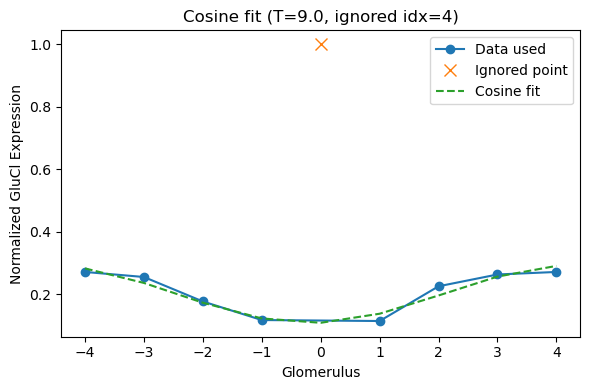

In [ ]:
col_to_fit = "percentage_total_green_avg"
df_to_fit = summarydf_all_halves_ihc

res = fit_cosine(
    df_to_fit,
    y_col=col_to_fit,
    x_col="glomerulus",
    ignore_idx=4,          # mask index 4
    T_fixed=9.0,           # set period to 9
    estimate_T=False       # fix T
)

print(f"A={res['params']['A']:.6f}, T={res['params']['T']:.6f}, "
      f"phi={res['params']['phi']:.6f}, B={res['params']['B']:.6f} | "
      f"R^2={res['r2']:.6f}, RMSE={res['rmse']:.6f}")

plot_fit(res["x"], res["y_obs"], res["y_pred"],
         f"Cosine fit (T={res['params']['T']}, ignored idx=4)", "Normalized GluCl Expression",
         ignored_index=4, y_raw=res["y_raw"])

A=-0.199879, T=9.000000, phi=-0.004712, B=0.514388 | R^2=0.873207, RMSE=0.049471


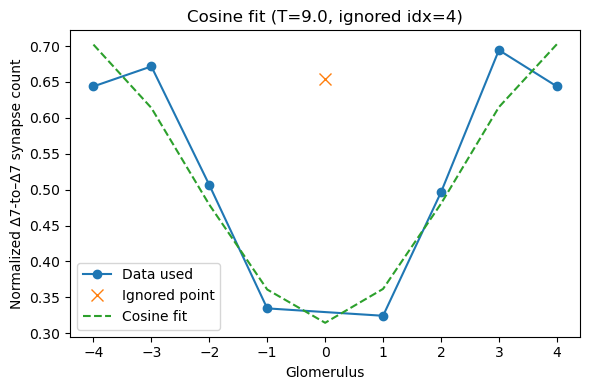

In [ ]:
col_to_fit = "percentage_SynapseCount_mean"
df_to_fit = summarydf_all_halves_commectome

res = fit_cosine(
    df_to_fit,
    y_col=col_to_fit,
    x_col="glomerulus",
    ignore_idx=4,          # mask index 4
    T_fixed=9.0,           # set period to 9
    estimate_T=False       # fix T
)

print(f"A={res['params']['A']:.6f}, T={res['params']['T']:.6f}, "
      f"phi={res['params']['phi']:.6f}, B={res['params']['B']:.6f} | "
      f"R^2={res['r2']:.6f}, RMSE={res['rmse']:.6f}")

plot_fit(res["x"], res["y_obs"], res["y_pred"],
         f"Cosine fit (T={res['params']['T']}, ignored idx=4)", "Normalized ∆7-to–∆7 synapse count",
         ignored_index=4, y_raw=res["y_raw"])

In [145]:
def plot_fit_used_only(x, y_obs, y_pred, title=None, *, show_full_fit=True):
    """
    Plot only the points actually used in the fit (non-NaN/finite in y_obs),
    plus the fitted cosine curve.

    x, y_obs, y_pred : 1-D arrays from your prep/fit
    show_full_fit : if True, draw the fit across all x; if False, only over used points
    """
    used = np.isfinite(x) & np.isfinite(y_obs)

    plt.figure(figsize=(6,4))
    # only the data used in the fit
    plt.plot(x[used], y_obs[used], marker="o", linestyle="-", label="Data used")

    # the fitted curve (full domain by default)
    if show_full_fit:
        plt.plot(x, y_pred, linestyle="--", label="Cosine fit")
    else:
        plt.plot(x[used], y_pred[used], linestyle="--", label="Cosine fit (used range)")

    plt.xlabel("Glomerulus")
    plt.ylabel("Value")
    plt.title(title or "Cosine fit (data used only)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_fit_used_only_from_result(res, title=None, *, show_full_fit=True):
    """
    Convenience wrapper for the dict returned by `fit_cosine(...)`.
    """
    plot_fit_used_only(
        res["x"], res["y_obs"], res["y_pred"],
        title=title, show_full_fit=show_full_fit
    )

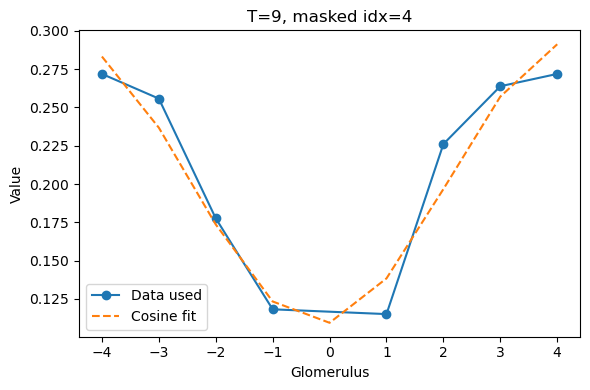

In [ ]:
res = fit_cosine(summarydf_all_halves_ihc,
                 y_col="percentage_total_green_avg",
                 x_col="glomerulus",
                 ignore_idx=4, T_fixed=9.0, estimate_T=False)

plot_fit_used_only_from_result(res, title="T=9, masked idx=4")

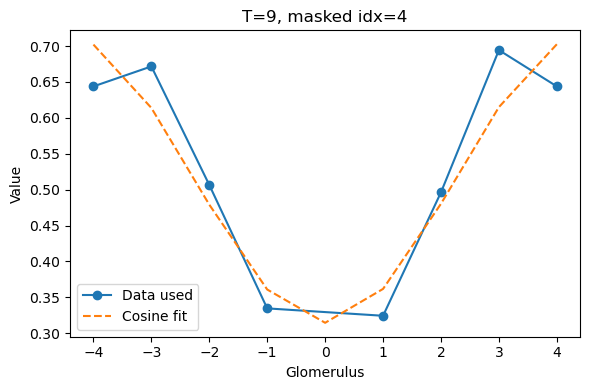

In [ ]:
res = fit_cosine(summarydf_all_halves_commectome,
                 y_col="percentage_SynapseCount_mean",
                 x_col="glomerulus",
                 ignore_idx=4, T_fixed=9.0, estimate_T=False)

plot_fit_used_only_from_result(res, title="T=9, masked idx=4")

# codes for 09022025 lab meeting

In [ ]:
# my data: 
y_full = summarydf_all_halves_ihc['percentage_total_green'].to_numpy()
x_full = summarydf_all_halves_ihc['glomerulus'].to_numpy()

# Cosine model
def cos_model(x, A, T, phi, B):
    return A * np.cos(2 * np.pi / T * (x - phi)) + B

# Metrics (ignores NaNs)
def metrics(y_obs, y_pred):
    m = ~np.isnan(y_obs)
    y_o, y_p = y_obs[m], y_pred[m]
    ss_res = np.sum((y_o - y_p)**2)
    ss_tot = np.sum((y_o - np.mean(y_o))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    rmse = np.sqrt(ss_res / len(y_o))
    return r2, rmse

# Plot helper: DATA = line with markers; FIT = line
def plot_fit(x, y_obs, y_pred, title, ignored_index=None):
    plt.figure(figsize=(6,4))
    m = ~np.isnan(y_obs)
    # line for data used (skips over NaNs so you'll see a gap at the ignored point)
    plt.plot(x[m], y_obs[m], marker="o", linestyle="-", label="Data used")
    if ignored_index is not None:
        # show the ignored point as an 'x' marker
        plt.plot(x[ignored_index], y_full[ignored_index], marker="x", linestyle="None", markersize=9, label="Ignored point")
    plt.plot(x, y_pred, linestyle="--", label="Cosine fit")
    plt.title(title)
    plt.xlabel("Glomerulus")
    plt.ylabel("Percentage")
    plt.legend()
    plt.tight_layout()
    plt.show()

curve_fit (T=9): A=-2.219518, phi=-0.182105, B=4.825762 | R^2=0.924768, RMSE=0.412283


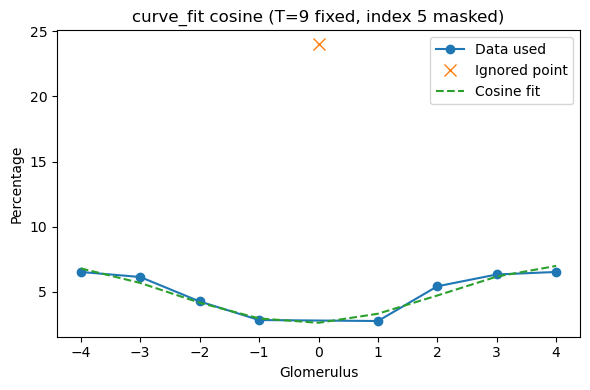

In [119]:
# Cell 3 — built-in curve_fit, T fixed at 9
y = y_full.copy()
ignore_idx = 4
y[ignore_idx] = np.nan
x = x_full.copy()

def cos_Tfixed(x, A, phi, B):
    return cos_model(x, A, 9.0, phi, B)

m = ~np.isnan(y)
p0 = [(np.nanmax(y)-np.nanmin(y))/2.0, 0.0, np.nanmean(y)]
popt, pcov = curve_fit(cos_Tfixed, x[m], y[m], p0=p0, maxfev=10000)
A, phi, B = popt

y_pred = cos_Tfixed(x, *popt)
r2, rmse = metrics(y, y_pred)
print(f"curve_fit (T=9): A={A:.6f}, phi={phi:.6f}, B={B:.6f} | R^2={r2:.6f}, RMSE={rmse:.6f}")
plot_fit(x, y, y_pred, "curve_fit cosine (T=9 fixed, index 5 masked)", ignored_index=ignore_idx)

In [258]:
def save_cosine_fit_svg(
    x, y_obs, y_pred, filename,
    *,
    show_full_fit: bool = True,
    xlabel: str = "Glomerulus",
    ylabel: str = "Value",
    title:  str | None = None,
    show_legend: bool = False,
    data_color: str = "tab:blue",  # <-- set this to choose the actual data curve color
    data_lw: float = 2.0,
    fit_color:  str = "0.5",       # <-- fixed default: gray
    fit_lw:  float = 3.0,
    fit_ls:  str = "--"            # <-- dashed fit line
) -> str:
    """
    Save a publication-style cosine fit plot as SVG.
    - Data curve uses `data_color`.
    - Cosine fit is gray dashed by default.
    """
    used = np.isfinite(x) & np.isfinite(y_obs)

    with mpl.rc_context({"svg.fonttype": "none"}):
        fig, ax = plt.subplots(figsize=(6, 4))

        # observed curve (used points only), solid
        ax.plot(x[used], y_obs[used], linestyle="-", linewidth=data_lw,
                color=data_color, label="Data (used)")

        # fitted curve (gray dashed by default)
        if show_full_fit:
            ax.plot(x, y_pred, linestyle=fit_ls, linewidth=fit_lw,
                    color=fit_color, label="Cosine fit")
        else:
            ax.plot(x[used], y_pred[used], linestyle=fit_ls, linewidth=fit_lw,
                    color=fit_color, label="Cosine fit")

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        if title:
            ax.set_title(title, pad=12)

        # clean aesthetics
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.2)
        ax.spines["bottom"].set_linewidth(1.2)
        ax.tick_params(direction="out", length=5, width=1)
        ax.grid(True, axis="y", alpha=0.15, linewidth=0.8)

        if show_legend:
            ax.legend(frameon=False)

        fig.tight_layout()
        out = Path(filename)
        out.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out, format="svg", bbox_inches="tight", transparent=True,
                    metadata={"Creator": "save_cosine_fit_svg"})
        plt.close(fig)
    return str(out)


def save_cosine_fit_svg_from_result(res: dict, filename: str | Path, **kwargs) -> str:
    """Wrapper for the dict returned by fit_cosine(...)."""
    return save_cosine_fit_svg(res["x"], res["y_obs"], res["y_pred"], filename, **kwargs)

In [261]:
res = fit_cosine(
    summarydf_all_halves_ihc,
    y_col="percentage_total_green_avg",
    x_col="glomerulus",
    ignore_idx=4, T_fixed=9.0, estimate_T=False
)

save_cosine_fit_svg_from_result(
    res, "cosine_fit-ihc.svg",
    xlabel="PB position (glomerulus)",
    ylabel="Percentage",
    title="Cosine fit (T=9, idx 4 masked)",
    data_color="tab:green",  # your chosen data curve color
    show_full_fit=True,
    show_legend=False
)

'cosine_fit-ihc.svg'

In [262]:
res = fit_cosine(
    summarydf_all_halves_commectome,
    y_col="percentage_SynapseCount_mean",
    x_col="glomerulus",
    ignore_idx=4, T_fixed=9.0, estimate_T=False
)

save_cosine_fit_svg_from_result(
    res, "cosine_fit-connectome.svg",
    xlabel="PB position (glomerulus)",
    ylabel="Percentage",
    title="Cosine fit (T=9, idx 4 masked)",
    data_color="black",  # your chosen data curve color
    show_full_fit=True,
    show_legend=False
)


'cosine_fit-connectome.svg'

<font size="10">PART FIVE</font>

# get numbers for prism significance test

In [242]:
dict_all_halves_ihc['fly12_L_combine19_reordered_add1row']

,glomerulus,mean_red,mean_green,total_red,total_green,percentage_total_green,percentage_total_green_divided_by_d7countall,percentage_total_green_divided_by_d7%all
0,L7,700.9,239.1,4.752996e+08,16043139.0,0.265285,0.005969,0.412090
1,L6,554.3,214.2,3.870011e+08,9527123.0,0.157538,0.003376,0.234576
2,L5,485.7,204.3,1.886452e+08,3764394.0,0.062247,0.001838,0.122899
3,L4,428.5,196.7,2.717540e+08,7088330.0,0.117211,0.005566,0.350324
4,L3,843.7,201.8,2.053103e+09,60475056.0,1.000000,0.023083,1.528318
5,L2,479.4,194.2,2.346397e+08,2245639.0,0.037133,0.001758,0.114506
6,L1+9,604.1,224.8,2.913234e+08,9605923.0,0.158841,0.004736,0.320094
7,L8,779.5,240.8,3.550039e+08,17225573.0,0.284838,0.006013,0.410253
8,added,700.9,239.1,4.752996e+08,16043139.0,0.265285,0.005969,0.412090


In [243]:
# Build axon_vs_farthestdendrite from each DF in the dict
rows = []
for name, df in dict_all_halves_ihc.items():
    # pick the column name you actually have
    col = ('percentage_total_green_divided_by_d7countall' if 'percentage_total_green_divided_by_d7countall' in df.columns
           else ('divided_by_d7all' if 'divided_by_d7all' in df.columns else None))
    if col is None:
        # skip if neither column exists
        continue

    s = pd.to_numeric(df[col], errors='coerce')
    if len(s) < 9:
        # need at least 9 rows to read indices 0,4,8
        continue

    rows.append({
        #'axon':                float(s.iloc[4]),  # center row
        'farthestdendrite_L': float(s.iloc[0]),  # leftmost
        'closetdendrite_L': float(s.iloc[3]),
        'farthestdendrite_R': float(s.iloc[8]),  # rightmost
        'closetdendrite_R': float(s.iloc[5]),
    })

axon_vs_farthestdendrite = pd.DataFrame(rows, columns=['farthestdendrite_L','closetdendrite_L', 'farthestdendrite_R','closetdendrite_R'])
axon_vs_farthestdendrite

,farthestdendrite_L,closetdendrite_L,farthestdendrite_R,closetdendrite_R
0,0.005969,0.005566,0.005969,0.001758
1,0.003796,0.003546,0.003796,0.011722
2,0.006055,0.003017,0.006055,0.005036
3,0.001021,0.002917,0.001021,0.001034
4,0.004682,0.003705,0.004682,0.002229
5,0.006334,0.005997,0.006334,0.009534
6,0.005118,0.002855,0.005118,0.006514
7,0.003638,0.008082,0.003638,0.006401
8,0.003502,0.004712,0.003502,0.004635
9,0.005273,0.001858,0.005273,0.004037


In [246]:
def build_axon_vs_dendrite_table(
    dfs: Dict[str, pd.DataFrame],
    *,
    y_col: Optional[str] = None,                      # pick a specific column to use
    fallback_cols: Iterable[str] = (
        "percentage_total_green_divided_by_d7countall",
        "divided_by_d7all",
    ),                                                # tried in order if y_col is None
    use_label_positions: bool = False,                # if True, locate positions via glomerulus labels
    x_col: str = "glomerulus",                        # label column if use_label_positions=True
    min_len: int = 9,                                 # need at least 9 rows for index-based mapping
) -> pd.DataFrame:
    """
    For each DataFrame in `dfs`, extract five values from the chosen column:
      - 'axon'               -> center (index 4, or label 0)
      - 'farthestdendrite_L' -> leftmost (index 0, or label -4)
      - 'closetdendrite_L'   -> near-left (index 3, or label -1)
      - 'farthestdendrite_R' -> rightmost (index 8, or label +4)
      - 'closetdendrite_R'   -> near-right (index 5, or label +1)

    Returns a DataFrame with those columns; one row per input DF (order of dfs keys).
    """
    # index-based positions for 9 rows
    idx_positions = {
        "axon": 4,
        "farthestdendrite_L": 0,
        "closetdendrite_L": 3,
        "farthestdendrite_R": 8,
        "closetdendrite_R": 5,
    }
    # label-based positions if glomerulus runs from -4..4
    label_positions = {
        "axon": 0,
        "farthestdendrite_L": -4,
        "closetdendrite_L": -1,
        "farthestdendrite_R": 4,
        "closetdendrite_R": 1,
    }

    rows = []
    for name, df in dfs.items():
        if not isinstance(df, pd.DataFrame) or df.empty:
            continue

        # which value column to use?
        col = y_col
        if col is None:
            col = next((c for c in fallback_cols if c in df.columns), None)
        if col is None:
            # no usable column in this DF
            continue

        s = pd.to_numeric(df[col], errors="coerce")
        if use_label_positions:                             # i will always use index to choose rows
            # map labels to row indices (first occurrence)
            if x_col not in df.columns:
                continue
            labels = pd.to_numeric(df[x_col], errors="coerce")
            label_to_idx = {v: i for i, v in enumerate(labels)}
            try:
                row = {
                    "axon":                float(s.iloc[label_to_idx[label_positions["axon"]]]),
                    "farthestdendrite_L":  float(s.iloc[label_to_idx[label_positions["farthestdendrite_L"]]]),
                    "closetdendrite_L":    float(s.iloc[label_to_idx[label_positions["closetdendrite_L"]]]),
                    "farthestdendrite_R":  float(s.iloc[label_to_idx[label_positions["farthestdendrite_R"]]]),
                    "closetdendrite_R":    float(s.iloc[label_to_idx[label_positions["closetdendrite_R"]]]),
                }
            except KeyError:
                # some required label missing -> skip this DF
                continue
        else:
            # simple index-based selection; need at least 9 rows
            if len(s) < min_len:
                continue
            row = {
                "axon":                float(s.iloc[idx_positions["axon"]]),
                "farthestdendrite_L":  float(s.iloc[idx_positions["farthestdendrite_L"]]),
                "closetdendrite_L":    float(s.iloc[idx_positions["closetdendrite_L"]]),
                "farthestdendrite_R":  float(s.iloc[idx_positions["farthestdendrite_R"]]),
                "closetdendrite_R":    float(s.iloc[idx_positions["closetdendrite_R"]]),
            }

        # optionally keep the source key (useful for merging back later)
        row["_source"] = name
        rows.append(row)

    cols = ["axon", "farthestdendrite_L", "closetdendrite_L", "farthestdendrite_R", "closetdendrite_R"]
    out = pd.DataFrame(rows)
    if not out.empty:
        out = out[["_source"] + cols]  # keep a stable column order
    else:
        out = pd.DataFrame(columns=["_source"] + cols)
    return out

In [ ]:
axon_vs_farthestdendrite_1 = build_axon_vs_dendrite_table(
    dfs=dict_all_halves_ihc,
    y_col="percentage_total_green_divided_by_d7countall"
)
axon_vs_farthestdendrite_1

,_source,axon,farthestdendrite_L,closetdendrite_L,farthestdendrite_R,closetdendrite_R
0,fly12_L_combine19_reordered_add1row,0.023083,0.005969,0.005566,0.005969,0.001758
1,fly12_R_combine19_reordered_add1row,0.023083,0.003796,0.003546,0.003796,0.011722
2,fly13_L_combine19_reordered_add1row,0.023083,0.006055,0.003017,0.006055,0.005036
3,fly13_R_combine19_reordered_add1row,0.023083,0.001021,0.002917,0.001021,0.001034
4,fly14_L_combine19_reordered_add1row,0.023083,0.004682,0.003705,0.004682,0.002229
5,fly14_R_combine19_reordered_add1row,0.023083,0.006334,0.005997,0.006334,0.009534
6,fly15_L_combine19_reordered_add1row,0.023083,0.005118,0.002855,0.005118,0.006514
7,fly15_R_combine19_reordered_add1row,0.023083,0.003638,0.008082,0.003638,0.006401
8,fly16_L_combine19_reordered_add1row,0.023083,0.003502,0.004712,0.003502,0.004635
9,fly16_R_combine19_reordered_add1row,0.023083,0.005273,0.001858,0.005273,0.004037


In [249]:
axon_vs_farthestdendrite_2 = build_axon_vs_dendrite_table(
    dfs=dict_all_halves_ihc,
    y_col="percentage_total_green"
)
axon_vs_farthestdendrite_2

,_source,axon,farthestdendrite_L,closetdendrite_L,farthestdendrite_R,closetdendrite_R
0,fly12_L_combine19_reordered_add1row,1.0,0.265285,0.117211,0.265285,0.037133
1,fly12_R_combine19_reordered_add1row,1.0,0.168701,0.074682,0.168701,0.247562
2,fly13_L_combine19_reordered_add1row,1.0,0.269090,0.063533,0.269090,0.106365
3,fly13_R_combine19_reordered_add1row,1.0,0.045357,0.061440,0.045357,0.021828
4,fly14_L_combine19_reordered_add1row,1.0,0.208079,0.078029,0.208079,0.047078
5,fly14_R_combine19_reordered_add1row,1.0,0.281479,0.126293,0.281479,0.201343
6,fly15_L_combine19_reordered_add1row,1.0,0.227455,0.060119,0.227455,0.137576
7,fly15_R_combine19_reordered_add1row,1.0,0.161694,0.170201,0.161694,0.135189
8,fly16_L_combine19_reordered_add1row,1.0,0.155640,0.099241,0.155640,0.097894
9,fly16_R_combine19_reordered_add1row,1.0,0.234350,0.039132,0.234350,0.085255
